<a href="https://colab.research.google.com/github/Lieqi-Liu/Math-168/blob/main/Math168.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/stockData.csv')

# Display the first few rows
display(df.head())

,Unnamed: 0,Date,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NVDA,PG,XOM,TSM,AVGO,ORCL
0,1,2013-01-02,16.60,12.87,17.96,49.25,31.50,27.81,22.24,0.29,47.64,52.04,12.86,2.37,28.76
1,2,2013-01-03,16.39,12.92,17.97,49.19,31.44,27.58,21.94,0.29,47.34,51.95,12.85,2.38,28.45
2,3,2013-01-04,15.93,12.96,18.33,49.75,32.00,28.56,21.53,0.30,47.44,52.19,12.76,2.36,28.70
3,4,2013-01-07,15.84,13.42,18.25,49.64,32.03,29.22,21.49,0.29,47.11,51.59,12.57,2.35,28.55
4,5,2013-01-08,15.88,13.32,18.21,49.65,32.09,28.86,21.38,0.29,47.04,51.91,12.46,2.34,28.56


In [ ]:
from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# Convert 'Date' to datetime and set it as the index
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

# Drop unnecessary columns like 'Unnamed: 0'
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# Calculate the 100-day moving average
ma_100 = df.rolling(window=100).mean()

# Display the last few rows of the moving average data
display(ma_100.tail())

,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NVDA,PG,XOM,TSM,AVGO,ORCL
Date,,,,,,,,,,,,,
2025-12-24,254.5202,227.9605,259.6715,187.8414,303.4943,703.7338,504.9310,182.6359,149.3570,112.3065,274.5852,342.4767,248.9903
2025-12-26,255.2286,228.1482,260.8629,188.2334,303.8721,702.7435,504.5491,182.7588,149.3101,112.4434,275.3024,343.0793,248.4195
2025-12-29,255.8376,228.2458,262.0406,188.6262,304.2087,701.6220,504.1891,182.8470,149.2383,112.6015,276.0114,343.5674,247.8150
2025-12-30,256.3722,228.3398,263.2169,189.0032,304.5857,700.6745,503.8738,182.9149,149.1551,112.7697,276.5951,344.0393,247.2989
2025-12-31,256.8018,228.4211,264.3358,189.3629,304.9327,699.5939,503.5079,182.9531,149.0644,112.9231,277.2298,344.4616,246.7533


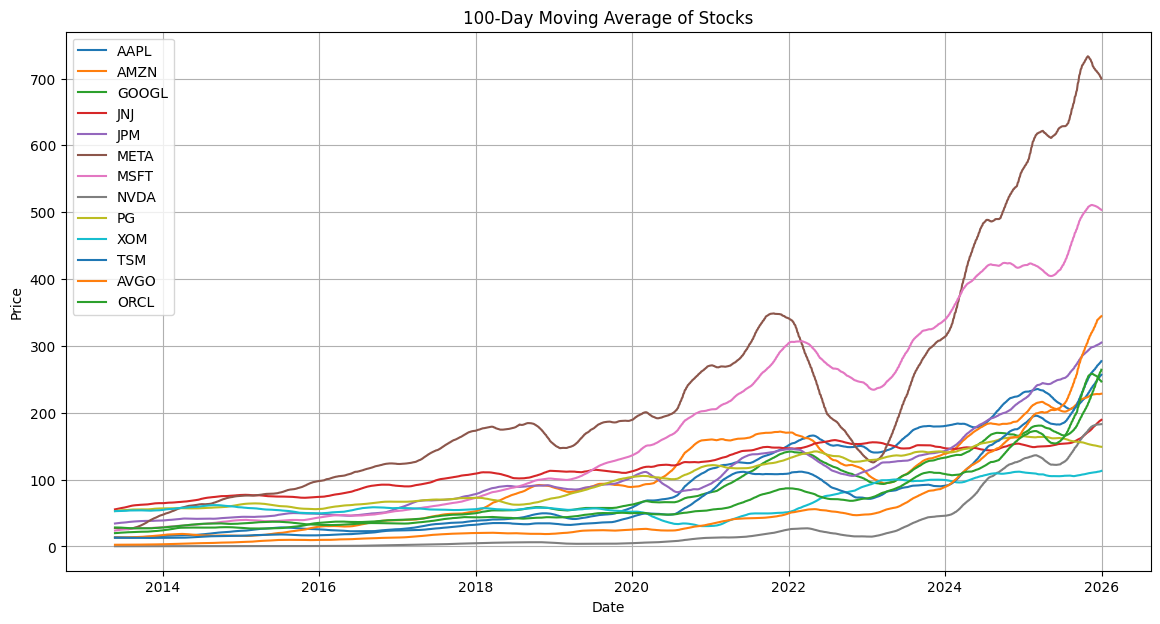

In [ ]:
import matplotlib.pyplot as plt

# Plot the 100-day moving average
plt.figure(figsize=(14, 7))
for column in ma_100.columns:
    plt.plot(ma_100.index, ma_100[column], label=column)

plt.title('100-Day Moving Average of Stocks')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# Task
Use the stock data in the dataframe `df` (loaded from "/content/stockData.csv") to train a Linear Regression model. First, prepare the data by converting the Datetime index to a numeric format and splitting it into a training set (all data before the last month) and a test set (the last month). Then, train the model on the training set to predict stock prices for the test set, calculate the Mean Squared Error (MSE) for each stock, and visualize the actual vs. predicted prices for the last month.

## Prepare Data for Modeling

### Subtask:
Convert the Datetime index to a numeric format and split the data into training (pre-last month) and test (last month) sets.


**Reasoning**:
Create a new feature 'Date_ordinal' for regression, determine the cutoff date for the last month, split the data into training and testing sets, and prepare the feature matrices X_train and X_test.



In [ ]:
# Create Date_ordinal first
df['Date_ordinal'] = df.index.map(pd.Timestamp.toordinal)

# Determine cutoff date for the last month
cutoff_date = df.index.max() - pd.Timedelta(days=30)

# Split first
train_data = df[df.index < cutoff_date].copy()
test_data  = df[df.index >= cutoff_date].copy()

# Only scale actual stock columns, not Date_ordinal
stock_columns = [col for col in df.columns if col != 'Date_ordinal']

# Fit min-max scaling on TRAIN only
train_min = train_data[stock_columns].min()
train_max = train_data[stock_columns].max()
den = (train_max - train_min).replace(0, 1)   # avoid divide-by-zero

# Apply same train scaling to both train and test
train_data[stock_columns] = (train_data[stock_columns] - train_min) / den
test_data[stock_columns]  = (test_data[stock_columns] - train_min) / den

# Use Date_ordinal as feature without scaling
X_train = train_data['Date_ordinal'].values.reshape(-1, 1)
X_test  = test_data['Date_ordinal'].values.reshape(-1, 1)

# Print the shapes of the resulting datasets
print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

Train data shape: (3248, 14)
Test data shape: (22, 14)


In [ ]:
# # Create a new column 'Date_ordinal' converting the index to ordinal numbers
# df['Date_ordinal'] = df.index.map(pd.Timestamp.toordinal)

# price_cols = df.select_dtypes("number").columns

# # Min-max normalize per column (each ticker separately)
# df[price_cols] = (df[price_cols] - df[price_cols].min()) / (df[price_cols].max() - df[price_cols].min())

# # Determine the cutoff date for the last month (30 days)
# cutoff_date = df.index.max() - pd.Timedelta(days=30)

# # Split the data into training and test sets
# train_data = df[df.index < cutoff_date]
# test_data = df[df.index >= cutoff_date]

# # Create feature variables X_train and X_test
# X_train = train_data['Date_ordinal'].values.reshape(-1, 1)
# X_test = test_data['Date_ordinal'].values.reshape(-1, 1)

# # Print the shapes of the resulting datasets
# print(f"Train data shape: {train_data.shape}")
# print(f"Test data shape: {test_data.shape}")

## Train Linear Models, Predict, and Calculate MSE

### Subtask:
Train Linear Regression models for each stock, generate predictions for the test set, and compute the Mean Squared Error (MSE).


**Reasoning**:
Train a Linear Regression model for each stock using the training data, predict prices for the test set, and calculate the Mean Squared Error (MSE) for each prediction.



In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Initialize dictionaries to store predictions and MSE scores
predictions = {}
mse_scores = {}

# Identify stock columns (excluding 'Date_ordinal')
stock_columns = [col for col in train_data.columns if col != 'Date_ordinal']

# Iterate over each stock to train the model and make predictions
for stock in stock_columns:
    # Initialize the model
    model = LinearRegression()

    # Train the model
    model.fit(X_train, train_data[stock])

    # Make predictions
    pred = model.predict(X_test)
    predictions[stock] = pred

    # Calculate MSE
    mse = mean_squared_error(test_data[stock], pred)
    mse_scores[stock] = mse
    mean_mse = sum(mse_scores.values()) / len(mse_scores)

# Display the MSE scores
print("Mean Squared Error (MSE) for each stock:")
for stock, mse in mse_scores.items():
    print(f"{stock}: {mse:.4f}")

print("\nMean MSE for all stocks: ")
print(mean_mse)

Mean Squared Error (MSE) for each stock:
AAPL: 0.0559
AMZN: 0.0119
GOOGL: 0.2166
JNJ: 0.0464
JPM: 0.1432
META: 0.0521
MSFT: 0.0172
NVDA: 0.2203
PG: 0.0248
XOM: 0.0599
TSM: 0.2099
AVGO: 0.2949
ORCL: 0.0392

Mean MSE for all stocks: 
0.10709135138002707


# Task
Construct a stock relationship network using the data from the "/content/stockData.csv" file.

First, calculate the daily returns for each stock using the formula $(P_t - P_{t-1}) / P_{t-1}$.

Next, define two types of edges for the network:
1.  **Linear Edges**: Calculate the Pearson correlation coefficient matrix of the daily returns. Create an edge between stocks if the absolute correlation is greater than 0.7.
2.  **Association Edges**: Discretize the daily returns into binary values (1 for positive returns, 0 otherwise). Calculate the 'Lift' metric for every pair of stocks to measure co-movement. Create an edge if the Lift is greater than 1.7.

Finally, build a graph using NetworkX where nodes represent stocks and edges represent the identified relationships. Visualize the resulting network and print a summary of the number of edges found.

## Calculate Daily Returns

### Subtask:
Reload the dataset to ensure raw prices are used, then compute daily percentage returns.


**Reasoning**:
Reload the dataset to ensure raw prices are used, convert dates, drop unnecessary columns, and calculate daily returns.



In [ ]:
# Reload the dataset to get raw prices
df = pd.read_csv('/content/stockData.csv')

# Convert 'Date' to datetime and set it as the index
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)

# Drop unnecessary columns like 'Unnamed: 0'
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

# Calculate daily returns
daily_returns = df.pct_change()

# Drop the first row which contains NaN values
daily_returns.dropna(inplace=True)

# Display the first few rows of daily returns
display(daily_returns.head())

,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NVDA,PG,XOM,TSM,AVGO,ORCL
Date,,,,,,,,,,,,,
2013-01-03,-0.012651,0.003885,0.000557,-0.001218,-0.001905,-0.008270,-0.013489,0.000000,-0.006297,-0.001729,-0.000778,0.004219,-0.010779
2013-01-04,-0.028066,0.003096,0.020033,0.011384,0.017812,0.035533,-0.018687,0.034483,0.002112,0.004620,-0.007004,-0.008403,0.008787
2013-01-07,-0.005650,0.035494,-0.004364,-0.002211,0.000938,0.023109,-0.001858,-0.033333,-0.006956,-0.011496,-0.014890,-0.004237,-0.005226
2013-01-08,0.002525,-0.007452,-0.002192,0.000201,0.001873,-0.012320,-0.005119,0.000000,-0.001486,0.006203,-0.008751,-0.004255,0.000350
2013-01-09,-0.015743,0.000000,0.006590,0.004431,-0.000623,0.052668,0.005613,-0.034483,0.005315,-0.003853,0.000000,0.021368,0.000350


## Identify Linear Relationships (Pearson)

### Subtask:
Calculate the Pearson correlation matrix and identify stock pairs with high correlation (> 0.7).


**Reasoning**:
Calculate the Pearson correlation matrix and identify stock pairs with an absolute correlation coefficient greater than 0.7, avoiding self-loops and duplicates.



In [ ]:
# Calculate the Pearson correlation matrix
corr_matrix = daily_returns.corr(method='pearson')

# Initialize a list to store linear edges
linear_edges = []

# Iterate through the correlation matrix to find pairs with high correlation
# Use nested loops, but only check the upper triangle to avoid duplicates and self-loops
columns = corr_matrix.columns
for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        stock1 = columns[i]
        stock2 = columns[j]
        correlation = corr_matrix.iloc[i, j]

        if abs(correlation) > 0.5:
            linear_edges.append((stock1, stock2))

# Print the number of edges found and display the first few
print(f"Number of linear edges found: {len(linear_edges)}")
print("First 5 linear edges:", linear_edges[:5])

# Display the correlation matrix for reference (optional, first few rows/cols)
display(corr_matrix.iloc[:5, :5])

Number of linear edges found: 16
First 5 linear edges: [('AAPL', 'GOOGL'), ('AAPL', 'MSFT'), ('AMZN', 'GOOGL'), ('AMZN', 'META'), ('AMZN', 'MSFT')]


,AAPL,AMZN,GOOGL,JNJ,JPM
AAPL,1.000000,0.496954,0.544398,0.295231,0.399025
AMZN,0.496954,1.000000,0.611294,0.192702,0.313998
GOOGL,0.544398,0.611294,1.000000,0.277639,0.401737
JNJ,0.295231,0.192702,0.277639,1.000000,0.375236
JPM,0.399025,0.313998,0.401737,0.375236,1.000000


## Identify Association Relationships (Lift)

### Subtask:
Discretize daily returns into binary values (1 for positive, 0 otherwise), calculate the 'Lift' metric for each pair, and identify pairs with Lift > 1.7.

**Reasoning**:
Discretize the daily returns into binary values (1 for positive returns, 0 otherwise) and calculate the Lift metric for each pair of stocks to identify association edges.



In [ ]:
# Discretize daily returns: 1 if positive, 0 otherwise
binary_returns = (daily_returns > 0).astype(int)

# Initialize a list to store association edges
association_edges = []

# Calculate Lift for every pair of stocks
# Lift(A, B) = P(A and B) / (P(A) * P(B))
# P(A) is the probability that stock A has a positive return

# Calculate probabilities for each stock (P(A))
probs = binary_returns.mean()

columns = binary_returns.columns
num_samples = len(binary_returns)

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        stock1 = columns[i]
        stock2 = columns[j]

        # P(A and B): Probability that both stocks have positive returns
        # We can calculate this by counting rows where both are 1, divided by total rows
        # equivalent to (binary_returns[stock1] & binary_returns[stock2]).mean()
        prob_both = (binary_returns[stock1] & binary_returns[stock2]).mean()

        # Lift calculation
        prob_stock1 = probs[stock1]
        prob_stock2 = probs[stock2]

        if prob_stock1 > 0 and prob_stock2 > 0:
            lift = prob_both / (prob_stock1 * prob_stock2)
        else:
            lift = 0

        if lift > 1.3:
            association_edges.append((stock1, stock2))

# Print the number of association edges found and display the first few
print(f"Number of association edges found: {len(association_edges)}")
print("First 5 association edges:", association_edges[:5])

Number of association edges found: 22
First 5 association edges: [('AAPL', 'GOOGL'), ('AAPL', 'MSFT'), ('AAPL', 'NVDA'), ('AAPL', 'AVGO'), ('AMZN', 'GOOGL')]


## Build and Visualize Network

### Subtask:
Construct a NetworkX graph with stocks as nodes. Add 'Linear' edges (correlation > 0.7) and 'Association' edges (Lift > 1.7). Visualize the network and print a summary.

**Reasoning**:
The linear and association edges have been identified. The next logical step is to construct the network graph using NetworkX and visualize it. I will proceed directly to generating the code for this visualization, as previous attempts to add a markdown header may have caused issues.



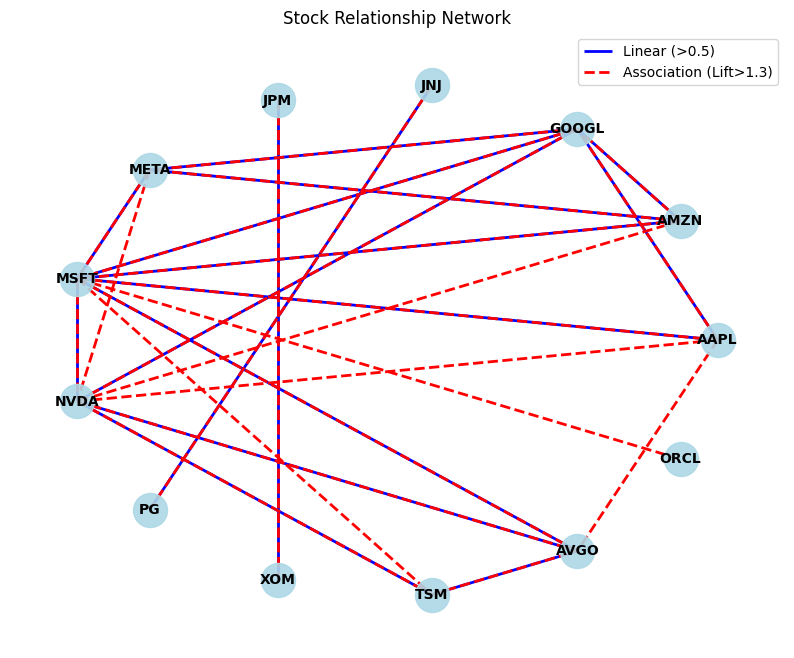

Total nodes: 13
Total edges: 22
Linear edges count: 16
Association edges count: 22


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Initialize the graph
G = nx.Graph()

# Add nodes (stocks)
stocks = daily_returns.columns
G.add_nodes_from(stocks)

# Add Linear edges (if any exist)
if 'linear_edges' in locals() and linear_edges:
    G.add_edges_from(linear_edges)

# Add Association edges (if any exist)
if 'association_edges' in locals() and association_edges:
    G.add_edges_from(association_edges)

# Visualize the network
plt.figure(figsize=(10, 8))

# Use a circular layout for better visibility of potential connections or isolated nodes
pos = nx.circular_layout(G)

# Draw nodes
nx.draw_networkx_nodes(G, pos, node_size=600, node_color='lightblue', alpha=0.9)

# Draw labels
nx.draw_networkx_labels(G, pos, font_size=10, font_weight='bold')

# Draw Linear Edges (Blue, Solid)
if 'linear_edges' in locals() and linear_edges:
    nx.draw_networkx_edges(G, pos, edgelist=linear_edges, edge_color='blue', width=2, label='Linear (>0.5)')

# Draw Association Edges (Red, Dashed)
if 'association_edges' in locals() and association_edges:
    nx.draw_networkx_edges(G, pos, edgelist=association_edges, edge_color='red', style='dashed', width=2, label='Association (Lift>1.3)')

plt.title('Stock Relationship Network')
plt.axis('off')

# Add a legend if there are edges
if ('linear_edges' in locals() and linear_edges) or ('association_edges' in locals() and association_edges):
    plt.legend()

plt.show()

# Print summary
print(f"Total nodes: {G.number_of_nodes()}")
print(f"Total edges: {G.number_of_edges()}")
print(f"Linear edges count: {len(linear_edges) if 'linear_edges' in locals() else 0}")
print(f"Association edges count: {len(association_edges) if 'association_edges' in locals() else 0}")

## Build Graph-Based Prediction Models

### Subtask:
Implement a regular GNN, an LSTM-GNN, and Attention-GNN for stock prediciton.



**Reasoning**:
Use the stock relationship network as input to a series of graph-based prediction models. Starting with a regular GNN as the baseline model, then add an LSTM component to capture temporal patterns, and finally apply attention to learn which neighboring stocks are most influential for prediction.

## Implement a Regular GNN

> Add blockquote



### Subtask:
Train a regular GNN on the stock relationship network for stock prediction.

**Reasoning**:
Use the regular GNN as the first graph-based baseline model. This will test whether graph structure alone improves prediction compared to models that treat each stock independently.

In [ ]:
# Build G_train from TRAIN ONLY data:
train_returns = daily_returns.loc[daily_returns.index < cutoff_date].copy()

corr_matrix = train_returns.corr(method='pearson')

# Initialize a list to store linear edges
linear_edges = []

# Iterate through the correlation matrix to find pairs with high correlation
# Use nested loops, but only check the upper triangle to avoid duplicates and self-loops
columns = corr_matrix.columns
for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        stock1 = columns[i]
        stock2 = columns[j]
        correlation = corr_matrix.iloc[i, j]
        if abs(correlation) > 0.5:
            linear_edges.append((stock1, stock2))



# Discretize daily returns: 1 if positive, 0 otherwise
binary_returns = (train_returns > 0).astype(int)

# Initialize a list to store association edges
association_edges = []

# Calculate Lift for every pair of stocks
# Lift(A, B) = P(A and B) / (P(A) * P(B))
# P(A) is the probability that stock A has a positive return

# Calculate probabilities for each stock (P(A))
probs = binary_returns.mean()

columns = binary_returns.columns
num_samples = len(binary_returns)

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        stock1 = columns[i]
        stock2 = columns[j]

        # P(A and B): Probability that both stocks have positive returns
        # We can calculate this by counting rows where both are 1, divided by total rows
        # equivalent to (binary_returns[stock1] & binary_returns[stock2]).mean()
        prob_both = (binary_returns[stock1] & binary_returns[stock2]).mean()

        # Lift calculation
        prob_stock1 = probs[stock1]
        prob_stock2 = probs[stock2]

        if prob_stock1 > 0 and prob_stock2 > 0:
            lift = prob_both / (prob_stock1 * prob_stock2)
        else:
            lift = 0

        if lift > 1.3:
            association_edges.append((stock1, stock2))


# Initialize the graph
G_train = nx.Graph()

# Add nodes (stocks)
stocks = train_returns.columns
G_train.add_nodes_from(stocks)

# Add Linear edges (if any exist)
if 'linear_edges' in locals() and linear_edges:
    G_train.add_edges_from(linear_edges)

# Add Association edges (if any exist)
if 'association_edges' in locals() and association_edges:
    G_train.add_edges_from(association_edges)

In [ ]:
# ============================================================
# Fix 1: Avoid leakage (scaling + graph construction)
#   - Split first (train = before last month, test = last month)
#   - Fit min–max scaling on TRAIN only (train min/max), then
#     apply the same scaling to both train and test
#   - Build the network graph G using TRAIN ONLY returns
#     (Pearson/Lift/Granger edges must not use test-month data)
#   - Using test data in scaling or in G makes MSE unrealistically good
# Fix 2: Increase training speed
#   - Use mini-batch DataLoader to avoid looping over each time step t
#   - Each step trains on a batch xb: [B, N] instead of a single sample [N]
#   - This greatly reduces Python overhead and speeds up training on GPU (e.g., Colab T4)
# ============================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import networkx as nx
from sklearn.metrics import mean_squared_error

stocks = list(G_train.nodes())
num_stocks = len(stocks)

# same last-month split
cutoff_date = df.index.max() - pd.Timedelta(days=30)
train_data = df[df.index < cutoff_date].copy()
test_data = df[df.index >= cutoff_date].copy()

# FIX 1: scale using TRAIN ONLY
train_min = train_data[stocks].min()
train_max = train_data[stocks].max()
den = (train_max - train_min).replace(0, 1)  # avoid division by zero

train_data[stocks] = (train_data[stocks] - train_min) / den
test_data[stocks] = (test_data[stocks] - train_min) / den


# one-step prediction: day t -> day t+1
X_train = torch.tensor(train_data[stocks].values[:-1], dtype=torch.float32)
y_train = torch.tensor(train_data[stocks].values[1:], dtype=torch.float32)

test_context = pd.concat([train_data[stocks].tail(1), test_data[stocks]], axis=0)
X_test = torch.tensor(test_context[stocks].values[:-1], dtype=torch.float32)
y_test = torch.tensor(test_context[stocks].values[1:], dtype=torch.float32)

A = nx.to_numpy_array(G_train, nodelist=stocks).astype(np.float32)
A = A + np.eye(num_stocks, dtype=np.float32)
deg = A.sum(axis=1)
D_inv_sqrt = np.diag(1.0 / np.sqrt(deg + 1e-8))
A_hat = D_inv_sqrt @ A @ D_inv_sqrt
A_hat = torch.tensor(A_hat, dtype=torch.float32)

class GCNLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.linear = nn.Linear(in_features, out_features)

    def forward(self, X, A):
        """
        X: [N, F] or [B, N, F]
        A: [N, N]
        """
        if X.dim() == 2:
            X = X.unsqueeze(0)          # [1, N, F]
        X = torch.matmul(A, X)          # [B, N, F]
        return self.linear(X)           # [B, N, out_features]

class StockGNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.gcn1 = GCNLayer(1, 16)
        self.gcn2 = GCNLayer(16, 1)

    def forward(self, x, A):
        unbatched = (x.dim() == 1)
        if unbatched:
          x = x.unsqueeze(0)
        x = x.unsqueeze(-1)
        x = self.gcn1(x, A)             # should output [B, N, 16]
        x = F.relu(x)
        x = self.gcn2(x, A)             # [B, N, 1]
        x = x.squeeze(-1)               # [B, N]
        if unbatched:
            x = x.squeeze(0)            # [N]
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = StockGNN().to(device)
A_hat = A_hat.to(device)
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test  = X_test.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.002, weight_decay=1e-5)
loss_fn = nn.MSELoss()
epochs = 100

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=256,   # try 128, 256, 512 on T4
    shuffle=True
)

train_loss_history = {}
epoch_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0.0
    count = 0

    for xb, yb in train_loader:               # xb: [B, N], yb: [B, N]
        optimizer.zero_grad()
        pred = model(xb, A_hat)               # pred: [B, N]
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        count += xb.size(0)

    avg_loss = total_loss / count
    epoch_losses.append(avg_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Train Loss: {total_loss:.4f}")

# same MSE calculation style as the linear model
model.eval()
predictions = []
with torch.no_grad():
    predictions = model(X_test, A_hat).cpu().numpy()

y_test_np = y_test.cpu().numpy() if hasattr(y_test, "cpu") else y_test.numpy()

mse_scores = {
    stock: mean_squared_error(y_test_np[:, i], predictions[:, i])
    for i, stock in enumerate(stocks)
}

mean_mse = float(np.mean(list(mse_scores.values())))

print("Mean Squared Error (MSE) for each stock:")
for stock, mse in mse_scores.items():
    print(f"{stock}: {mse:.4f}")

print("\nMean MSE for all stocks:")
print(mean_mse)


results = []
test_preds_dict = {}
y_test_dict = {}
model_name = "GCN"
results.append({
    "model": model_name,
    "mean_mse": float(mean_mse),
    "std_across_stocks": float(np.std(list(mse_scores.values()))),
    "n_stocks": len(mse_scores)
})

test_preds_dict[model_name] = predictions
y_test_dict[model_name] = y_test_np

train_loss_history[model_name] = epoch_losses

Epoch 0, Train Loss: 756.6966
Epoch 10, Train Loss: 42.8016
Epoch 20, Train Loss: 36.6721
Epoch 30, Train Loss: 36.1863
Epoch 40, Train Loss: 35.6680
Epoch 50, Train Loss: 35.1322
Epoch 60, Train Loss: 34.6124
Epoch 70, Train Loss: 34.1253
Epoch 80, Train Loss: 33.6842
Epoch 90, Train Loss: 33.2987
Mean Squared Error (MSE) for each stock:
AAPL: 0.0180
AMZN: 0.0041
GOOGL: 0.0030
JNJ: 0.0141
JPM: 0.0002
META: 0.0004
MSFT: 0.0485
NVDA: 0.0309
PG: 0.0151
XOM: 0.0003
TSM: 0.0370
AVGO: 0.0045
ORCL: 0.0026

Mean MSE for all stocks:
0.013745683576696767


In [ ]:
# import numpy as np
# import pandas as pd
# import torch
# import torch.nn as nn
# import torch.nn.functional as F
# import networkx as nx
# from sklearn.metrics import mean_squared_error

# stocks = list(df.select_dtypes("number").columns)
# num_stocks = len(stocks)

# # same min-max scaling as the linear model
# df[stocks] = (df[stocks] - df[stocks].min()) / (df[stocks].max() - df[stocks].min())

# # same last-month split
# cutoff_date = df.index.max() - pd.Timedelta(days=30)
# train_data = df[df.index < cutoff_date]
# test_data = df[df.index >= cutoff_date]

# # one-step prediction: day t -> day t+1
# X_train = torch.tensor(train_data[stocks].values[:-1], dtype=torch.float32)
# y_train = torch.tensor(train_data[stocks].values[1:], dtype=torch.float32)
# X_test = torch.tensor(test_data[stocks].values[:-1], dtype=torch.float32)
# y_test = torch.tensor(test_data[stocks].values[1:], dtype=torch.float32)

# # same graph, same GCN normalization
# A = nx.to_numpy_array(G, nodelist=stocks)
# A = A + np.eye(num_stocks)
# D = np.diag(np.sum(A, axis=1))
# D_inv_sqrt = np.linalg.inv(np.sqrt(D))
# A_hat = D_inv_sqrt @ A @ D_inv_sqrt
# A_hat = torch.tensor(A_hat, dtype=torch.float32)

# class GCNLayer(nn.Module):
#     def __init__(self, in_features, out_features):
#         super().__init__()
#         self.linear = nn.Linear(in_features, out_features)

#     def forward(self, X, A):
#         X = torch.matmul(A, X)   # graph propagation
#         return self.linear(X)

# class StockGNN(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.gcn1 = GCNLayer(1, 16)
#         self.gcn2 = GCNLayer(16, 1)

#     def forward(self, x, A):
#         x = x.unsqueeze(1)       # (num_stocks,) -> (num_stocks, 1)
#         x = self.gcn1(x, A)
#         x = F.relu(x)
#         x = self.gcn2(x, A)
#         return x.squeeze()

# model = StockGNN()
# optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
# loss_fn = nn.MSELoss()
# epochs = 100

# for epoch in range(epochs):
#     total_loss = 0
#     model.train()
#     for t in range(X_train.shape[0]):
#         optimizer.zero_grad()
#         pred = model(X_train[t], A_hat)
#         loss = loss_fn(pred, y_train[t])
#         loss.backward()
#         optimizer.step()
#         total_loss += loss.item()

#     if epoch % 10 == 0:
#         print(f"Epoch {epoch}, Train Loss: {total_loss:.4f}")

# # same MSE calculation style as the linear model
# model.eval()
# predictions = []
# with torch.no_grad():
#     for t in range(X_test.shape[0]):
#         pred = model(X_test[t], A_hat)
#         predictions.append(pred.numpy())

# predictions = np.array(predictions)

# mse_scores = {}
# for i, stock in enumerate(stocks):
#     mse_scores[stock] = mean_squared_error(y_test[:, i].numpy(), predictions[:, i])

# mean_mse = sum(mse_scores.values()) / len(mse_scores)

# print("Mean Squared Error (MSE) for each stock:")
# for stock, mse in mse_scores.items():
#     print(f"{stock}: {mse:.4f}")

# print("\nMean MSE for all stocks:")
# print(mean_mse)

## Implement a plain LSTM baseline


In [ ]:
stocks = list(G_train.nodes())
num_stocks = len(stocks)

# same last-month split
cutoff_date = df.index.max() - pd.Timedelta(days=30)
train_data = df[df.index < cutoff_date].copy()
test_data = df[df.index >= cutoff_date].copy()

seq_len = 5

# scale using TRAIN ONLY
train_min = train_data[stocks].min()
train_max = train_data[stocks].max()
den = (train_max - train_min).replace(0, 1)

train_scaled = ((train_data[stocks] - train_min) / den).copy()
test_scaled = ((test_data[stocks] - train_min) / den).copy()

# create sequences: past seq_len days -> next day
X_train, y_train = [], []
train_arr = train_scaled.values.astype(np.float32)

for t in range(seq_len, len(train_arr)):
    X_train.append(train_arr[t-seq_len:t])   # [seq_len, N]
    y_train.append(train_arr[t])             # [N]

test_arr = test_scaled.values.astype(np.float32)
test_context = np.vstack([train_arr[-seq_len:], test_arr])

X_test, y_test = [], []
for t in range(seq_len, len(test_context)):
    X_test.append(test_context[t-seq_len:t])
    y_test.append(test_context[t])

X_train = torch.tensor(np.array(X_train), dtype=torch.float32)
y_train = torch.tensor(np.array(y_train), dtype=torch.float32)
X_test = torch.tensor(np.array(X_test), dtype=torch.float32)
y_test = torch.tensor(np.array(y_test), dtype=torch.float32)


class PlainLSTM(nn.Module):
    """
    Standard multivariate LSTM baseline.
    Input:  [B, seq_len, N]
    Output: [B, N]
    """
    def __init__(self, num_stocks, hidden_size=32, num_layers=1, dropout=0.2):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size

        self.lstm = nn.LSTM(
            input_size=num_stocks,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc1 = nn.Linear(hidden_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, num_stocks)
        self.dropout = dropout

    def forward(self, x):
        # x: [B, seq_len, N]
        h, _ = self.lstm(x)              # [B, seq_len, hidden_size]
        h = h[:, -1, :]                  # [B, hidden_size]
        h = F.relu(self.fc1(h))
        h = F.dropout(h, p=self.dropout, training=self.training)
        out = self.fc2(h)                # [B, N]
        return out


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = PlainLSTM(num_stocks=num_stocks, hidden_size=16, num_layers=1, dropout=0.05).to(device)

X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.002, weight_decay=1e-5)
loss_fn = nn.MSELoss()
epochs = 100

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=256,
    shuffle=True
)

epoch_losses = []

for epoch in range(epochs):
    model.train()
    total_loss, count = 0.0, 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb)                 # [B, N]
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        count += xb.size(0)

    avg_loss = total_loss / count
    epoch_losses.append(avg_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Train Loss: {avg_loss:.4f}")

# test MSE
model.eval()
predictions = []
with torch.no_grad():
    predictions = model(X_test).detach().cpu().numpy()

y_test_np = y_test.detach().cpu().numpy()

mse_scores = {
    stock: mean_squared_error(y_test_np[:, i], predictions[:, i])
    for i, stock in enumerate(stocks)
}
mean_mse = float(np.mean(list(mse_scores.values())))

print("Mean Squared Error (MSE) for each stock:")
for stock, mse in mse_scores.items():
    print(f"{stock}: {mse:.4f}")

print("\nMean MSE for all stocks:")
print(mean_mse)

model_name = "Plain LSTM"
results.append({
    "model": model_name,
    "mean_mse": float(mean_mse),
    "std_across_stocks": float(np.std(list(mse_scores.values()))),
    "n_stocks": len(mse_scores)
})

test_preds_dict[model_name] = predictions
y_test_dict[model_name] = y_test_np
train_loss_history[model_name] = epoch_losses

Epoch 0, Train Loss: 0.1548
Epoch 10, Train Loss: 0.0084
Epoch 20, Train Loss: 0.0059
Epoch 30, Train Loss: 0.0044
Epoch 40, Train Loss: 0.0029
Epoch 50, Train Loss: 0.0026
Epoch 60, Train Loss: 0.0025
Epoch 70, Train Loss: 0.0023
Epoch 80, Train Loss: 0.0022
Epoch 90, Train Loss: 0.0019
Mean Squared Error (MSE) for each stock:
AAPL: 0.0053
AMZN: 0.0019
GOOGL: 0.0476
JNJ: 0.0287
JPM: 0.0018
META: 0.0125
MSFT: 0.0064
NVDA: 0.0012
PG: 0.0155
XOM: 0.0017
TSM: 0.0072
AVGO: 0.0111
ORCL: 0.0305

Mean MSE for all stocks:
0.013182112929196311


## Implement an LSTM-GNN

### Subtask:
Train an LSTM-GNN to combine temporal and graph-based information.

**Reasoning**:
Add an LSTM component to capture sequential stock behavior over time while still using the stock relationship network. This model will test whether combining temporal dynamics with graph structure improves prediction further.

In [ ]:
# ============================================================
# Fix 1: Avoid leakage (scaling + graph construction)
#   - Split first (train = before last month, test = last month)
#   - Fit min–max scaling on TRAIN only (train min/max), then
#     apply the same scaling to both train and test
#   - Build the network graph G using TRAIN ONLY returns
#     (Pearson/Lift/Granger edges must not use test-month data)
#   - Using test data in scaling or in G makes MSE unrealistically good
# Fix 2: Increase training speed
#   - Use mini-batch DataLoader to avoid looping over each time step t
#   - Each step trains on a batch xb: [B, seq_len, N] instead of a single sample [N]
#   - This greatly reduces Python overhead and speeds up training on GPU (e.g., Colab T4)
# ============================================================

stocks = list(G_train.nodes())
num_stocks = len(stocks)

# same last-month split
cutoff_date = df.index.max() - pd.Timedelta(days=30)
train_data = df[df.index < cutoff_date].copy()
test_data = df[df.index >= cutoff_date].copy()

seq_len = 5

# FIX 1: scale using TRAIN ONLY
train_min = train_data[stocks].min()
train_max = train_data[stocks].max()
den = (train_max - train_min).replace(0, 1)  # avoid division by zero

train_data[stocks] = (train_data[stocks] - train_min) / den
test_data[stocks] = (test_data[stocks] - train_min) / den

# create sequences: past seq_len days -> next day
X_train, y_train = [], []
train_arr = train_data[stocks].values.astype(np.float32)
for t in range(seq_len, len(train_arr)):
    X_train.append(train_arr[t-seq_len:t])
    y_train.append(train_arr[t])


test_arr  = test_data[stocks].values.astype(np.float32)
test_context = np.vstack([train_arr[-seq_len:], test_arr])

X_test, y_test = [], []
for t in range(seq_len, len(test_context)):
    X_test.append(test_context[t-seq_len:t])  # includes last train days for first prediction
    y_test.append(test_context[t])

X_train = torch.tensor(np.array(X_train), dtype=torch.float32)
y_train = torch.tensor(np.array(y_train), dtype=torch.float32)
X_test = torch.tensor(np.array(X_test), dtype=torch.float32)
y_test = torch.tensor(np.array(y_test), dtype=torch.float32)

A = nx.to_numpy_array(G_train, nodelist=stocks).astype(np.float32)
A = A + np.eye(num_stocks, dtype=np.float32)
deg = A.sum(axis=1)
D_inv_sqrt = np.diag(1.0 / np.sqrt(deg + 1e-8))
A = D_inv_sqrt @ A @ D_inv_sqrt
A = torch.tensor(A, dtype=torch.float32)

class LSTMGNN(nn.Module):
    """
    Per-stock LSTM encoder (shared across all stocks) + graph mixing.
    No cross-stock mixing occurs inside the LSTM.
    """
    def __init__(self, lstm_hidden=16, gnn_hidden=16, dropout=0.2):
        super().__init__()
        self.lstm_hidden = lstm_hidden
        self.lstm = nn.LSTM(input_size=1, hidden_size=lstm_hidden, batch_first=True)

        # node-wise transforms after graph mixing
        self.lin1 = nn.Linear(lstm_hidden, gnn_hidden)
        self.lin2 = nn.Linear(gnn_hidden, 1)
        self.dropout = dropout

    def forward(self, x, A):
        # x: [B, seq_len, N]
        B, T, N = x.shape

        # Run the SAME LSTM on each stock independently:
        x = x.permute(0, 2, 1).contiguous()   # [B, N, T]
        x = x.view(B * N, T, 1)               # [B*N, T, 1]

        h, _ = self.lstm(x)                   # [B*N, T, lstm_hidden]
        h = h[:, -1, :]                       # [B*N, lstm_hidden]
        h = h.view(B, N, self.lstm_hidden)    # [B, N, lstm_hidden]

        # Graph mixing (vectorized)
        h = torch.matmul(A, h)                # [B, N, lstm_hidden]
        h = F.relu(self.lin1(h))              # [B, N, gnn_hidden]
        h = F.dropout(h, p=self.dropout, training=self.training)

        h = torch.matmul(A, h)                # [B, N, gnn_hidden]
        out = self.lin2(h).squeeze(-1)        # [B, N]
        return out

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = LSTMGNN().to(device)
A = A.to(device)
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test  = X_test.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.002, weight_decay=1e-5)

loss_fn = nn.MSELoss()
epochs = 100

# FIX 2: mini-batch DataLoader
train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=256,   # try 64/128/256 on T4
    shuffle=True
)

epoch_losses = []

for epoch in range(epochs):
    model.train()
    total_loss, count = 0.0, 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb, A)              # [B, N]
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        count += xb.size(0)

    avg_loss = total_loss / count
    epoch_losses.append(avg_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Train Loss: {total_loss / count:.4f}")

# same test MSE calculation style
model.eval()
predictions = []
with torch.no_grad():
    predictions = model(X_test, A).detach().cpu().numpy()

y_test_np = y_test.detach().cpu().numpy()
mse_scores = {stock: mean_squared_error(y_test_np[:, i], predictions[:, i])
              for i, stock in enumerate(stocks)}
mean_mse = float(np.mean(list(mse_scores.values())))

print("Mean Squared Error (MSE) for each stock:")
for stock, mse in mse_scores.items():
    print(f"{stock}: {mse:.4f}")

print("\nMean MSE for all stocks:")
print(mean_mse)

model_name = "LSTM-GCN"
results.append({
    "model": model_name,
    "mean_mse": float(mean_mse),
    "std_across_stocks": float(np.std(list(mse_scores.values()))),
    "n_stocks": len(mse_scores)
})

test_preds_dict[model_name] = predictions
y_test_dict[model_name] = y_test_np

train_loss_history[model_name] = epoch_losses

Epoch 0, Train Loss: 0.0722
Epoch 10, Train Loss: 0.0123
Epoch 20, Train Loss: 0.0115
Epoch 30, Train Loss: 0.0111
Epoch 40, Train Loss: 0.0110
Epoch 50, Train Loss: 0.0107
Epoch 60, Train Loss: 0.0107
Epoch 70, Train Loss: 0.0106
Epoch 80, Train Loss: 0.0106
Epoch 90, Train Loss: 0.0106
Mean Squared Error (MSE) for each stock:
AAPL: 0.0197
AMZN: 0.0048
GOOGL: 0.0059
JNJ: 0.0195
JPM: 0.0021
META: 0.0003
MSFT: 0.0203
NVDA: 0.0153
PG: 0.0106
XOM: 0.0013
TSM: 0.0354
AVGO: 0.0067
ORCL: 0.0017

Mean MSE for all stocks:
0.011042638357209329


In [ ]:
# stocks = list(df.select_dtypes("number").columns)
# num_stocks = len(stocks)

# # same min-max scaling as the linear model
# df[stocks] = (df[stocks] - df[stocks].min()) / (df[stocks].max() - df[stocks].min())

# # same last-month split
# cutoff_date = df.index.max() - pd.Timedelta(days=30)
# train_data = df[df.index < cutoff_date]
# test_data = df[df.index >= cutoff_date]

# seq_len = 5

# # create sequences: past seq_len days -> next day
# X_train, y_train = [], []
# for t in range(seq_len, len(train_data)):
#     X_train.append(train_data[stocks].values[t-seq_len:t])
#     y_train.append(train_data[stocks].values[t])

# X_test, y_test = [], []
# for t in range(seq_len, len(test_data)):
#     X_test.append(test_data[stocks].values[t-seq_len:t])
#     y_test.append(test_data[stocks].values[t])

# X_train = torch.tensor(np.array(X_train), dtype=torch.float32)
# y_train = torch.tensor(np.array(y_train), dtype=torch.float32)
# X_test = torch.tensor(np.array(X_test), dtype=torch.float32)
# y_test = torch.tensor(np.array(y_test), dtype=torch.float32)

# # same graph but normalized
# A = nx.to_numpy_array(G, nodelist=stocks)
# A = A + np.eye(num_stocks)
# D = np.diag(np.sum(A, axis=1))
# D_inv_sqrt = np.linalg.inv(np.sqrt(D))
# A = D_inv_sqrt @ A @ D_inv_sqrt
# A = torch.tensor(A, dtype=torch.float32)

# class LSTMGNN(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.lstm = nn.LSTM(input_size=num_stocks, hidden_size=num_stocks, batch_first=True)
#         self.gnn1 = nn.Linear(1, 16)
#         self.gnn2 = nn.Linear(16, 1)

#     def forward(self, x, A):
#         x, _ = self.lstm(x)
#         x = x[:, -1, :]

#         out = []
#         for i in range(x.shape[0]):
#             h = x[i].unsqueeze(1)
#             h = A @ h
#             h = self.gnn1(h)
#             h = F.relu(h)
#             h = F.dropout(h, p=0.2, training=self.training)
#             h = A @ h
#             h = self.gnn2(h)
#             out.append(h.squeeze())

#         return torch.stack(out)

# model = LSTMGNN()
# optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)

# loss_fn = nn.MSELoss()
# epochs = 100

# for epoch in range(epochs):
#     model.train()
#     optimizer.zero_grad()
#     pred = model(X_train, A)
#     loss = loss_fn(pred, y_train)
#     loss.backward()
#     optimizer.step()

#     if epoch % 10 == 0:
#         print(f"Epoch {epoch}, Train Loss: {loss.item():.4f}")

# # same test MSE calculation style
# model.eval()
# with torch.no_grad():
#     predictions = model(X_test, A).numpy()

# mse_scores = {}
# for i, stock in enumerate(stocks):
#     mse_scores[stock] = mean_squared_error(y_test[:, i].numpy(), predictions[:, i])

# mean_mse = sum(mse_scores.values()) / len(mse_scores)

# print("Mean Squared Error (MSE) for each stock:")
# for stock, mse in mse_scores.items():
#     print(f"{stock}: {mse:.4f}")

# print("\nMean MSE for all stocks:")
# print(mean_mse)


## Implement an Attention-GNN

### Subtask
Train an Attention-GNN to learn weighted relationships between stocks

**Reasoning**:
Use an attention mechanism so the model can assign different importance to neighboring stocks in the graph. This will test whether selectively weighting stock relationships leads to better prediction performance.

In [ ]:
# ============================================================
# Fix 1: Avoid leakage (scaling + graph construction)
#   - Split first (train = before last month, test = last month)
#   - Fit min–max scaling on TRAIN only (train min/max), then
#     apply the same scaling to both train and test
#   - Build the network graph G using TRAIN ONLY returns
#     (Pearson/Lift/Granger edges must not use test-month data)
#   - Using test data in scaling or in G makes MSE unrealistically good
# Fix 2: Increase training speed
#   - Use mini-batch DataLoader to avoid looping over each time step t
#   - Each step trains on a batch xb: [B, N] instead of a single sample [N]
#   - This greatly reduces Python overhead and speeds up training on GPU (e.g., Colab T4)
# ============================================================

stocks = list(G_train.nodes())
num_stocks = len(stocks)

#  last-month
cutoff_date = df.index.max() - pd.Timedelta(days=30)
train_data = df[df.index < cutoff_date].copy()
test_data = df[df.index >= cutoff_date].copy()

# FIX 1: scale using TRAIN ONLY
train_min = train_data[stocks].min()
train_max = train_data[stocks].max()
den = (train_max - train_min).replace(0, 1)  # avoid division by zero

train_data[stocks] = (train_data[stocks] - train_min) / den
test_data[stocks] = (test_data[stocks] - train_min) / den

# one-step prediction
X_train = torch.tensor(train_data[stocks].values[:-1], dtype=torch.float32)
y_train = torch.tensor(train_data[stocks].values[1:], dtype=torch.float32)
test_context = pd.concat([train_data[stocks].tail(1), test_data[stocks]], axis=0)
X_test = torch.tensor(test_context[stocks].values[:-1], dtype=torch.float32)
y_test = torch.tensor(test_context[stocks].values[1:], dtype=torch.float32)

A = nx.to_numpy_array(G_train, nodelist=stocks).astype(np.float32)
A = A + np.eye(num_stocks, dtype=np.float32)
A_mask = torch.tensor(A > 0, dtype=torch.bool)

class AttnGNNLayer(nn.Module):
    """
    Vectorized attention-based message passing (GAT-style, single head).
    Supports:
      X:      [N, Fin] or [B, N, Fin]
      A_mask: [N, N] boolean (True = edge allowed)
    """
    def __init__(self, in_features, out_features, negative_slope=0.2, attn_dropout=0.0):
        super().__init__()
        self.W = nn.Linear(in_features, out_features, bias=False)
        self.attn_l = nn.Linear(out_features, 1, bias=False)
        self.attn_r = nn.Linear(out_features, 1, bias=False)
        self.negative_slope = negative_slope
        self.attn_dropout = attn_dropout

    def forward(self, X, A_mask):
        unbatched = (X.dim() == 2)
        if unbatched:
            X = X.unsqueeze(0)  # [1, N, Fin]

        H = self.W(X)  # [B, N, Fout]

        # e_ij = LeakyReLU(a_l(Hi) + a_r(Hj))  -> [B, N, N]
        el = self.attn_l(H)                 # [B, N, 1]
        er = self.attn_r(H)                 # [B, N, 1]
        e  = el + er.transpose(1, 2)        # [B, N, N]
        e  = F.leaky_relu(e, self.negative_slope)

        # mask non-edges
        e = e.masked_fill(~A_mask.unsqueeze(0), float("-inf"))

        alpha = F.softmax(e, dim=-1)        # [B, N, N]
        if self.attn_dropout > 0:
            alpha = F.dropout(alpha, p=self.attn_dropout, training=self.training)

        out = torch.matmul(alpha, H)        # [B, N, Fout]

        if unbatched:
            out = out.squeeze(0)            # [N, Fout]
        return out

class StockAttnGNN(nn.Module):
    """
    One-step Attention-GNN for your setup:
      x: [N] or [B, N]  -> predict y: [N] or [B, N]
    """
    def __init__(self, hidden=16, dropout=0.2):
        super().__init__()
        self.att1 = AttnGNNLayer(1, hidden, attn_dropout=dropout)
        self.att2 = AttnGNNLayer(hidden, 1, attn_dropout=0.0)
        self.dropout = dropout

    def forward(self, x, A_mask):
        unbatched = (x.dim() == 1)
        if unbatched:
            x = x.unsqueeze(0)              # [1, N]

        X = x.unsqueeze(-1)                 # [B, N, 1]
        X = self.att1(X, A_mask)            # [B, N, hidden]
        X = F.relu(X)
        X = F.dropout(X, p=self.dropout, training=self.training)
        X = self.att2(X, A_mask)            # [B, N, 1]
        X = X.squeeze(-1)                   # [B, N]

        if unbatched:
            X = X.squeeze(0)                # [N]
        return X


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = StockAttnGNN(hidden=16, dropout=0.05).to(device)
A_mask = A_mask.to(device)

X_train = X_train.to(device)   # [T, N]
y_train = y_train.to(device)   # [T, N]
X_test  = X_test.to(device)    # [Tt, N]

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=256,
    shuffle=True
)

optimizer = torch.optim.Adam(model.parameters(), lr=0.002, weight_decay=1e-5)
loss_fn = nn.MSELoss()
epochs = 100

epoch_losses = []

for epoch in range(epochs):
    model.train()
    total_loss, count = 0.0, 0

    for xb, yb in train_loader:          # xb [B,N], yb [B,N]
        optimizer.zero_grad()
        pred = model(xb, A_mask)         # [B,N]
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        count += xb.size(0)

    avg_loss = total_loss / count
    epoch_losses.append(avg_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Train Loss: {total_loss / count:.4f}")

model.eval()
predictions = []
with torch.no_grad():
    predictions = model(X_test, A_mask).detach().cpu().numpy()  # [Tt, N]

y_test_np = y_test.numpy()
mse_scores = {stock: mean_squared_error(y_test_np[:, i], predictions[:, i])
              for i, stock in enumerate(stocks)}
mean_mse = float(np.mean(list(mse_scores.values())))

print("Mean Squared Error (MSE) for each stock:")
for stock, mse in mse_scores.items():
    print(f"{stock}: {mse:.4f}")

print("\nMean MSE for all stocks:")
print(mean_mse)

model_name = "Attn-GNN"
results.append({
    "model": model_name,
    "mean_mse": float(mean_mse),
    "std_across_stocks": float(np.std(list(mse_scores.values()))),
    "n_stocks": len(mse_scores)
})

test_preds_dict[model_name] = predictions
y_test_dict[model_name] = y_test_np

train_loss_history[model_name] = epoch_losses

Epoch 0, Train Loss: 0.0828
Epoch 10, Train Loss: 0.0118
Epoch 20, Train Loss: 0.0115
Epoch 30, Train Loss: 0.0114
Epoch 40, Train Loss: 0.0113
Epoch 50, Train Loss: 0.0113
Epoch 60, Train Loss: 0.0112
Epoch 70, Train Loss: 0.0111
Epoch 80, Train Loss: 0.0112
Epoch 90, Train Loss: 0.0112
Mean Squared Error (MSE) for each stock:
AAPL: 0.0112
AMZN: 0.0008
GOOGL: 0.0079
JNJ: 0.0220
JPM: 0.0014
META: 0.0023
MSFT: 0.0008
NVDA: 0.0005
PG: 0.0086
XOM: 0.0009
TSM: 0.0078
AVGO: 0.0028
ORCL: 0.0461

Mean MSE for all stocks:
0.008698839721126625


In [ ]:
# stocks = list(df.select_dtypes("number").columns)
# num_stocks = len(stocks)

# #  min-max scaling
# df[stocks] = (df[stocks] - df[stocks].min()) / (df[stocks].max() - df[stocks].min())

# #  last-month
# cutoff_date = df.index.max() - pd.Timedelta(days=30)
# train_data = df[df.index < cutoff_date]
# test_data = df[df.index >= cutoff_date]

# # one-step prediction
# X_train = torch.tensor(train_data[stocks].values[:-1], dtype=torch.float32)
# y_train = torch.tensor(train_data[stocks].values[1:], dtype=torch.float32)
# X_test = torch.tensor(test_data[stocks].values[:-1], dtype=torch.float32)
# y_test = torch.tensor(test_data[stocks].values[1:], dtype=torch.float32)

# # keep the same graph
# A = nx.to_numpy_array(G, nodelist=stocks)
# A = A + np.eye(num_stocks)
# A = torch.tensor(A > 0, dtype=torch.bool)

# class GATLayer(nn.Module):
#     def __init__(self, in_features, out_features):
#         super().__init__()
#         self.W = nn.Linear(in_features, out_features, bias=False)
#         self.a = nn.Linear(2 * out_features, 1, bias=False)

#     def forward(self, X, A):
#         H = self.W(X)
#         N = H.size(0)

#         h_i = H.unsqueeze(1).repeat(1, N, 1)
#         h_j = H.unsqueeze(0).repeat(N, 1, 1)
#         e = self.a(torch.cat([h_i, h_j], dim=-1)).squeeze(-1)
#         e = F.leaky_relu(e, 0.2)

#         e = e.masked_fill(~A, float('-inf'))
#         alpha = F.softmax(e, dim=1)

#         return alpha @ H

# class StockGAT(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.gat1 = GATLayer(1, 16)
#         self.gat2 = GATLayer(16, 1)

#     def forward(self, x, A):
#         x = x.reshape(-1, 1)
#         x = self.gat1(x, A)
#         x = F.relu(x)
#         x = F.dropout(x, p=0.2, training=self.training)
#         x = self.gat2(x, A)
#         return x.squeeze()

# model = StockGAT()
# optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=1e-4)
# loss_fn = nn.MSELoss()
# epochs = 100

# for epoch in range(epochs):
#     total_loss = 0
#     model.train()
#     for t in range(X_train.shape[0]):
#         optimizer.zero_grad()
#         pred = model(X_train[t], A)
#         loss = loss_fn(pred, y_train[t])
#         loss.backward()
#         optimizer.step()
#         total_loss += loss.item()

#     if epoch % 10 == 0:
#         print(f"Epoch {epoch}, Train Loss: {total_loss / X_train.shape[0]:.4f}")

# model.eval()
# predictions = []
# with torch.no_grad():
#     for t in range(X_test.shape[0]):
#         pred = model(X_test[t], A)
#         predictions.append(pred.numpy())

# predictions = np.array(predictions)

# mse_scores = {}
# for i, stock in enumerate(stocks):
#     mse_scores[stock] = mean_squared_error(y_test[:, i].numpy(), predictions[:, i])

# mean_mse = sum(mse_scores.values()) / len(mse_scores)

# print("Mean Squared Error (MSE) for each stock:")
# for stock, mse in mse_scores.items():
#     print(f"{stock}: {mse:.4f}")

# print("\nMean MSE for all stocks:")
# print(mean_mse)

## Implement a GAT


In [ ]:
from statsmodels.tsa.stattools import grangercausalitytests

stocks = list(G_train.nodes())
num_stocks = len(stocks)

# last-month split
cutoff_date = df.index.max() - pd.Timedelta(days=30)
train_prices = df.loc[df.index < cutoff_date, stocks].copy()
test_prices  = df.loc[df.index >= cutoff_date, stocks].copy()

train_ret = train_prices.pct_change().dropna()
test_ret  = test_prices.pct_change().dropna()

max_lag = 5
p_thresh = 0.05
A = np.zeros((num_stocks, num_stocks), dtype=np.float32)
W = np.zeros((num_stocks, num_stocks), dtype=np.float32)

for i, target in enumerate(stocks):
    for j, cause in enumerate(stocks):
        if i == j:
            continue
        try:
            data = train_ret[[target, cause]].dropna()
            if len(data) < (max_lag + 10):
                continue

            res = grangercausalitytests(data, maxlag=max_lag)  # (you already silenced prints)
            pvals = [res[lag][0]["ssr_ftest"][1] for lag in range(1, max_lag + 1)]
            p_min = float(np.min(pvals))
            p_adj = min(1.0, p_min * max_lag)

            # if p_adj < p_thresh:
            #     A[i, j] = 1.0  # target i listens to cause j
            if p_adj < p_thresh:
                A[i, j] = 1.0  # target i listens to cause j
                W[i, j] = -np.log(p_adj + 1e-12)
        except Exception:
            pass



k = 3  # try 2–5 (3 is a good start)
A_pruned = np.zeros_like(A)

for i in range(num_stocks):  # target i
    incoming = np.where(A[i] > 0)[0]  # causes j
    if len(incoming) == 0:
        continue
    # pick top-k strongest by W
    top = incoming[np.argsort(W[i, incoming])[::-1][:k]]
    A_pruned[i, top] = 1.0

A = A_pruned


# Build boolean edge mask for GAT (directed) + self loops
A_mask = torch.tensor(A > 0, dtype=torch.bool)
A_mask.fill_diagonal_(True)

train_min = train_prices.min()
train_max = train_prices.max()
den = (train_max - train_min).replace(0, 1)

train_scaled = (train_prices - train_min) / den
test_scaled  = (test_prices  - train_min) / den

X_train = torch.tensor(train_scaled.values[:-1], dtype=torch.float32)
y_train = torch.tensor(train_scaled.values[1:],  dtype=torch.float32)

# add 1-step context so first test prediction is: last train day -> first test day
test_context = pd.concat([train_scaled.tail(1), test_scaled], axis=0)
X_test = torch.tensor(test_context.values[:-1], dtype=torch.float32)
y_test = torch.tensor(test_context.values[1:],  dtype=torch.float32)

class AttnGNNLayer(nn.Module):
    """
    GAT-style masked attention (single head).
    Aggregates for node i over sources j where A_mask[i,j] == True.
    """
    def __init__(self, in_features, out_features, negative_slope=0.2, attn_dropout=0.0):
        super().__init__()
        self.W = nn.Linear(in_features, out_features, bias=False)
        self.attn_l = nn.Linear(out_features, 1, bias=False)
        self.attn_r = nn.Linear(out_features, 1, bias=False)
        self.negative_slope = negative_slope
        self.attn_dropout = attn_dropout

    def forward(self, X, A_mask):
        unbatched = (X.dim() == 2)
        if unbatched:
            X = X.unsqueeze(0)  # [1, N, Fin]

        H = self.W(X)  # [B, N, Fout]

        el = self.attn_l(H)                 # [B, N, 1]
        er = self.attn_r(H)                 # [B, N, 1]
        e  = el + er.transpose(1, 2)        # [B, N, N]
        e  = F.leaky_relu(e, self.negative_slope)

        e = e.masked_fill(~A_mask.unsqueeze(0), float("-inf"))
        alpha = F.softmax(e, dim=-1)        # [B, N, N]
        if self.attn_dropout > 0:
            alpha = F.dropout(alpha, p=self.attn_dropout, training=self.training)

        out = torch.matmul(alpha, H)        # [B, N, Fout]
        return out.squeeze(0) if unbatched else out

class StockGAT(nn.Module):
    def __init__(self, hidden=16, dropout=0.2):
        super().__init__()
        self.att1 = AttnGNNLayer(1, hidden, attn_dropout=dropout)
        self.att2 = AttnGNNLayer(hidden, 1, attn_dropout=0.0)
        self.dropout = dropout

    def forward(self, x, A_mask):
        unbatched = (x.dim() == 1)
        if unbatched:
            x = x.unsqueeze(0)          # [1, N]

        h = x.unsqueeze(-1)             # [B, N, 1]
        h = self.att1(h, A_mask)        # [B, N, hidden]
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = self.att2(h, A_mask)        # [B, N, 1]
        h = h.squeeze(-1)               # [B, N]
        return h.squeeze(0) if unbatched else h

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = StockGAT(hidden=16, dropout=0).to(device)
A_mask = A_mask.to(device)

X_train = X_train.to(device)
y_train = y_train.to(device)
X_test  = X_test.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.002, weight_decay=1e-5)
loss_fn = nn.MSELoss()
epochs = 100

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=256,
    shuffle=True)

epoch_losses = []

for epoch in range(epochs):
    model.train()
    total_loss, count = 0.0, 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = model(xb, A_mask)     # <-- uses directed Granger mask
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * xb.size(0)
        count += xb.size(0)

    avg_loss = total_loss / count
    epoch_losses.append(avg_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Train Loss: {total_loss / count:.6f}")

model.eval()
predictions = []
with torch.no_grad():
    predictions = model(X_test, A_mask).detach().cpu().numpy()

y_test_np = y_test.detach().cpu().numpy()
mse_scores = {stocks[i]: mean_squared_error(y_test_np[:, i], predictions[:, i])
              for i in range(num_stocks)}
mean_mse = float(np.mean(list(mse_scores.values())))

print("Mean Squared Error (MSE) for each stock:")
for stock, mse in mse_scores.items():
    print(f"{stock}: {mse:.6f}")
print("\nMean MSE for all stocks:")
print(mean_mse)

model_name = "Granger-GAT"
results.append({
    "model": model_name,
    "mean_mse": float(mean_mse),
    "std_across_stocks": float(np.std(list(mse_scores.values()))),
    "n_stocks": len(mse_scores)
})

test_preds_dict[model_name] = predictions
y_test_dict[model_name] = y_test_np

train_loss_history[model_name] = epoch_losses

Streaming output truncated to the last 5000 lines.
ssr based chi2 test:   chi2=22.9278 , p=0.0003  , df=5
likelihood ratio test: chi2=22.8471 , p=0.0004  , df=5
parameter F test:         F=4.5700  , p=0.0004  , df_denom=3231, df_num=5

Granger Causality
number of lags (no zero) 1
ssr based F test:         F=10.1372 , p=0.0015  , df_denom=3243, df_num=1
ssr based chi2 test:   chi2=10.1465 , p=0.0014  , df=1
likelihood ratio test: chi2=10.1307 , p=0.0015  , df=1
parameter F test:         F=10.1372 , p=0.0015  , df_denom=3243, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=8.2028  , p=0.0003  , df_denom=3240, df_num=2
ssr based chi2 test:   chi2=16.4309 , p=0.0003  , df=2
likelihood ratio test: chi2=16.3894 , p=0.0003  , df=2
parameter F test:         F=8.2028  , p=0.0003  , df_denom=3240, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=5.3672  , p=0.0011  , df_denom=3237, df_num=3
ssr based chi2 test:   chi2=16.1365 ,

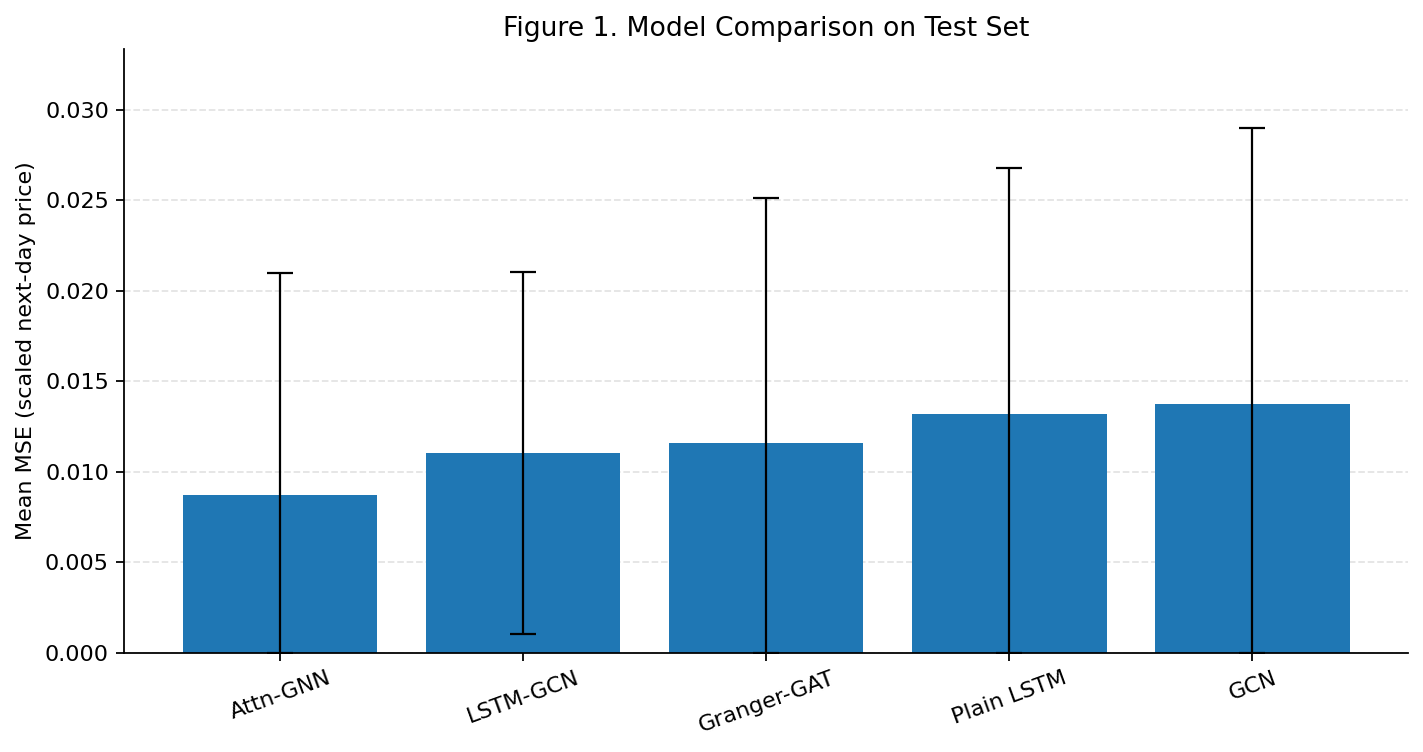

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_res = pd.DataFrame(results).sort_values("mean_mse", ascending=True).reset_index(drop=True)

means = df_res["mean_mse"].to_numpy()
stds  = df_res["std_across_stocks"].to_numpy()

# Prevent error bars from going below 0 (MSE can't be negative)
lower_err = np.minimum(stds, means)
upper_err = stds
yerr = np.vstack([lower_err, upper_err])

fig, ax = plt.subplots(figsize=(9, 4.8), dpi=160)

ax.bar(
    df_res["model"],
    means,
    yerr=yerr,
    capsize=6,
    error_kw=dict(lw=1, capthick=1)
)

ax.set_ylabel("Mean MSE (scaled next-day price)")
ax.set_title("Figure 1. Model Comparison on Test Set")

# Cleaner look
ax.yaxis.grid(True, linestyle="--", alpha=0.35)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(axis="x", rotation=20, labelsize=10)
ax.tick_params(axis="y", labelsize=10)

# Headroom
ymax = (means + upper_err).max()
ax.set_ylim(0, ymax * 1.15)

fig.tight_layout()
plt.show()

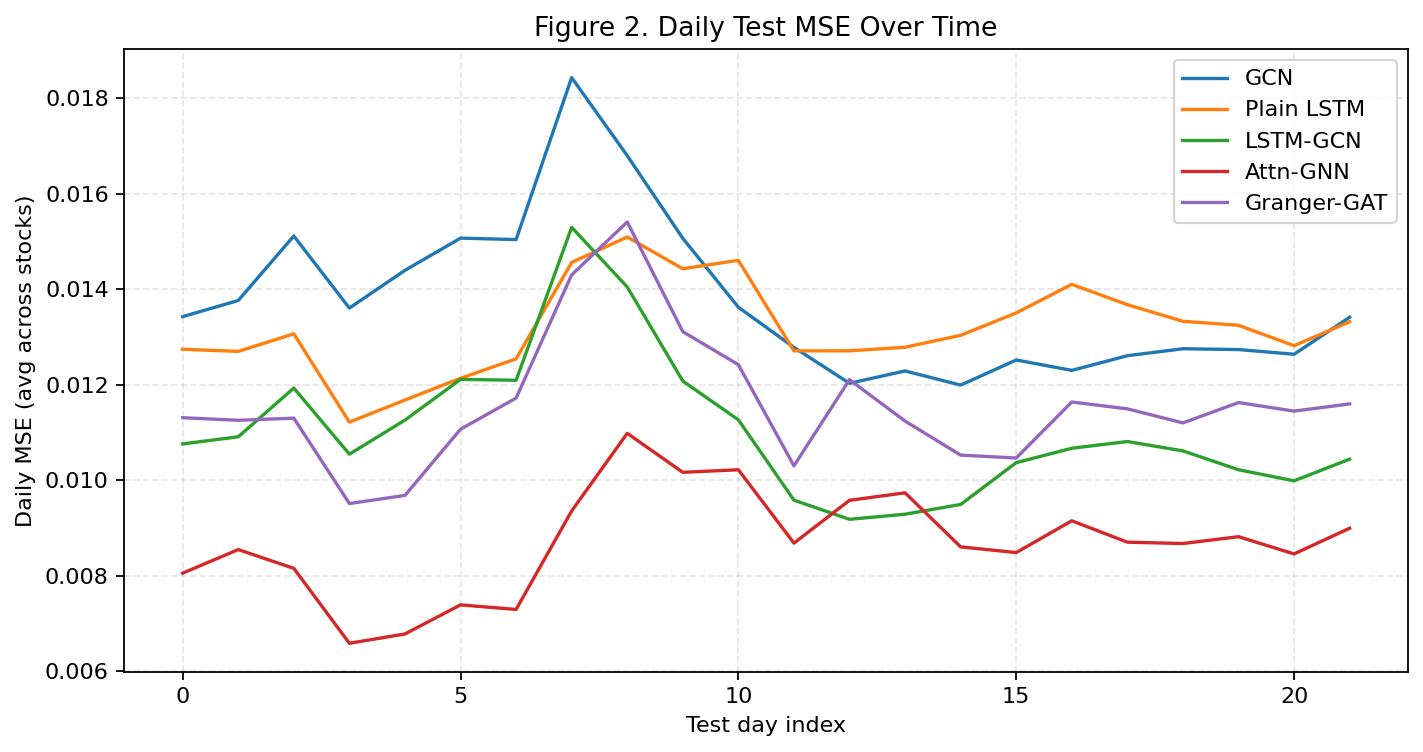

In [ ]:
plt.figure(figsize=(9, 4.8), dpi=160)

for model_name, preds in test_preds_dict.items():
    y_true = y_test_dict[model_name]
    T = min(len(preds), len(y_true))
    daily_mse = ((preds[:T] - y_true[:T])**2).mean(axis=1)  # [T]
    plt.plot(daily_mse, label=model_name)

plt.title("Figure 2. Daily Test MSE Over Time")
plt.ylabel("Daily MSE (avg across stocks)")
plt.xlabel("Test day index")
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

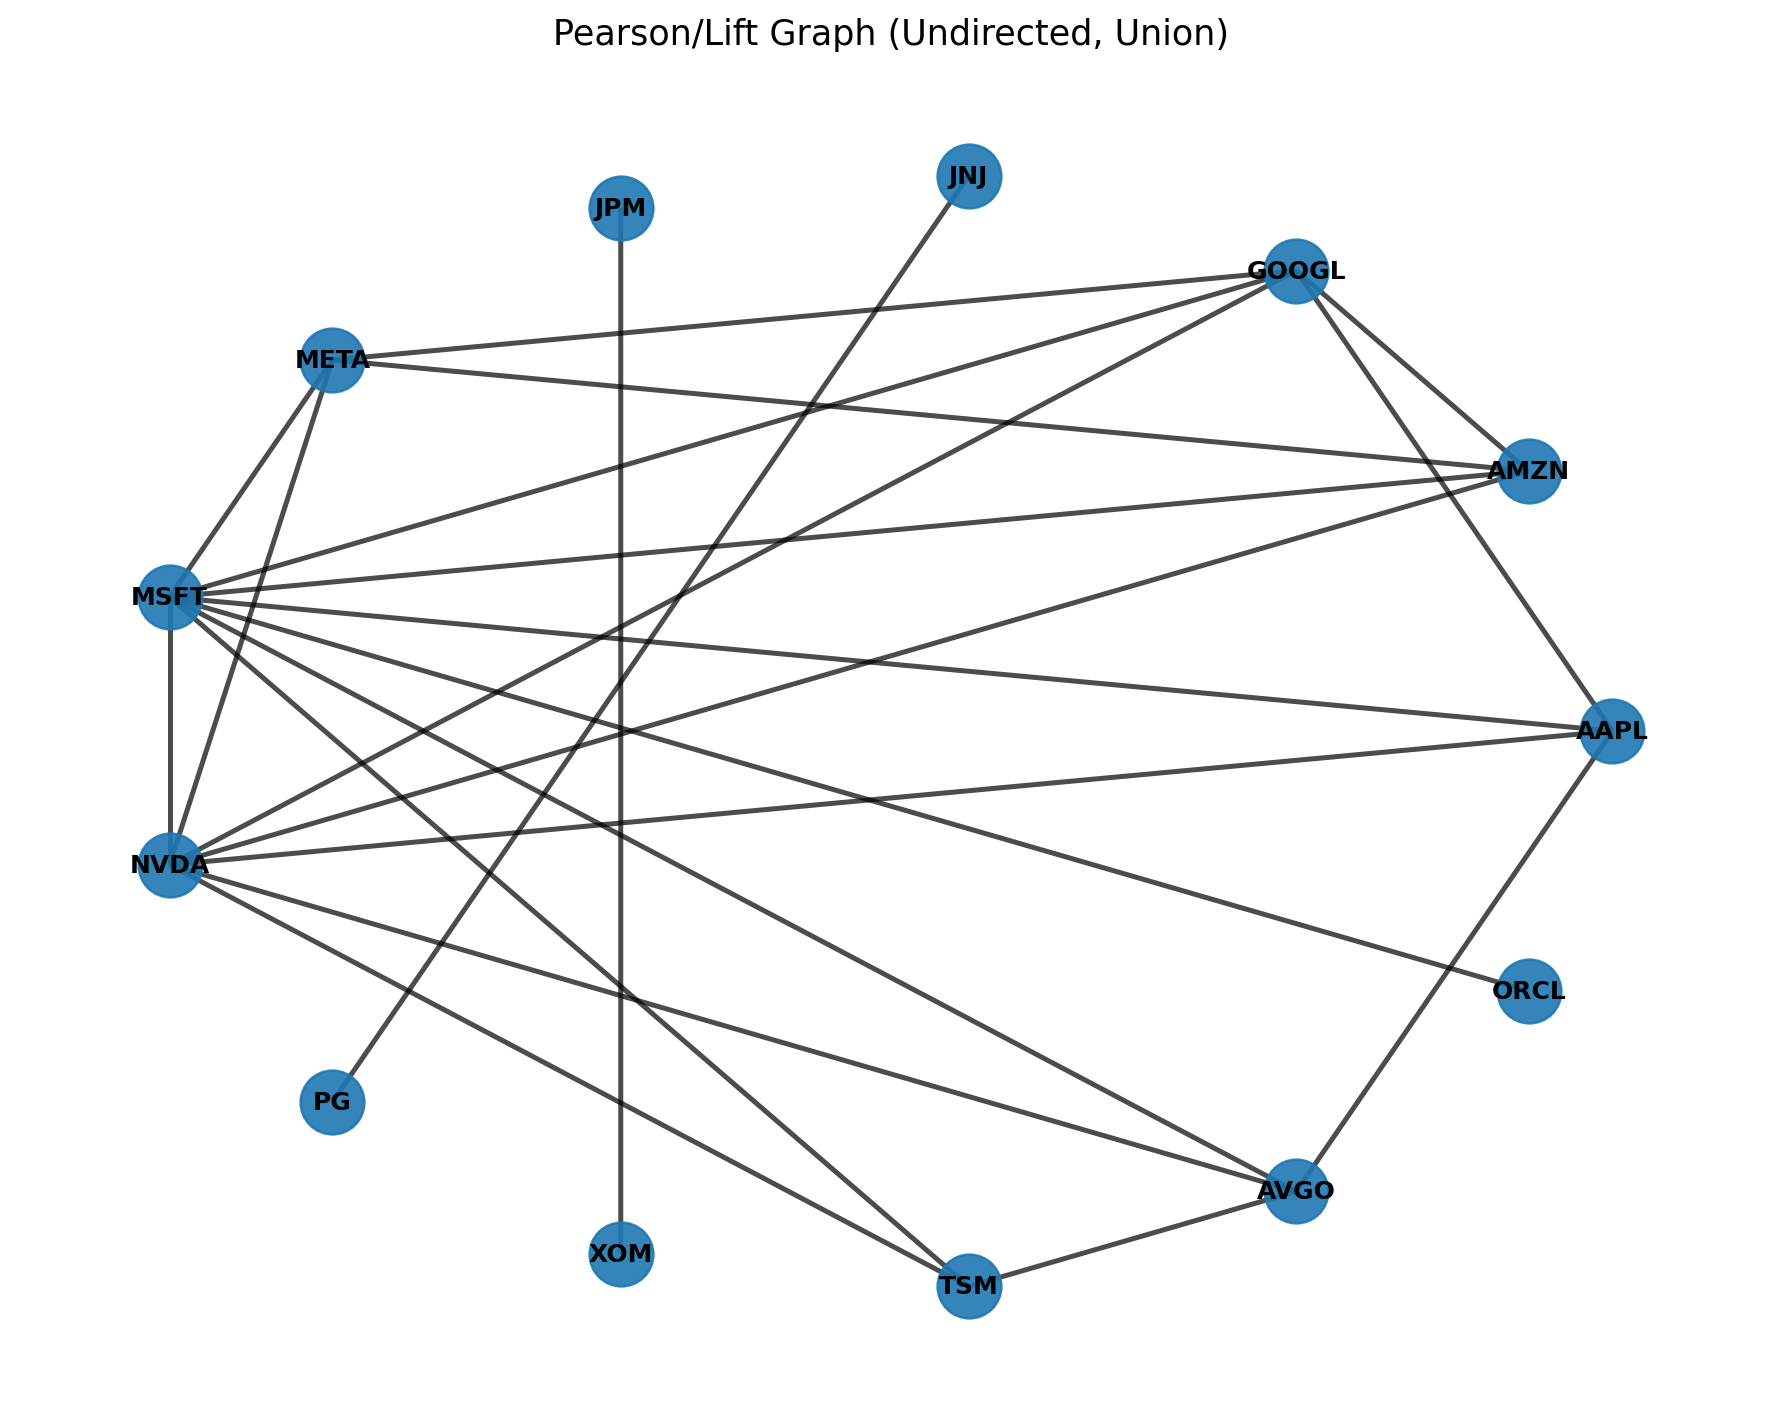

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

stocks = list(train_returns.columns)  # or your ticker list
G = nx.Graph()
G.add_nodes_from(stocks)

# Union of edges (treat as undirected)
edge_set = {tuple(sorted(e)) for e in (linear_edges + association_edges)}
edges = list(edge_set)

G.add_edges_from(edges)

plt.figure(figsize=(10, 8), dpi=180)
pos = nx.circular_layout(G)

nx.draw_networkx_nodes(G, pos, node_size=650, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")
nx.draw_networkx_edges(G, pos, edgelist=edges, width=2, alpha=0.7)

plt.title("Pearson/Lift Graph (Undirected, Union)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

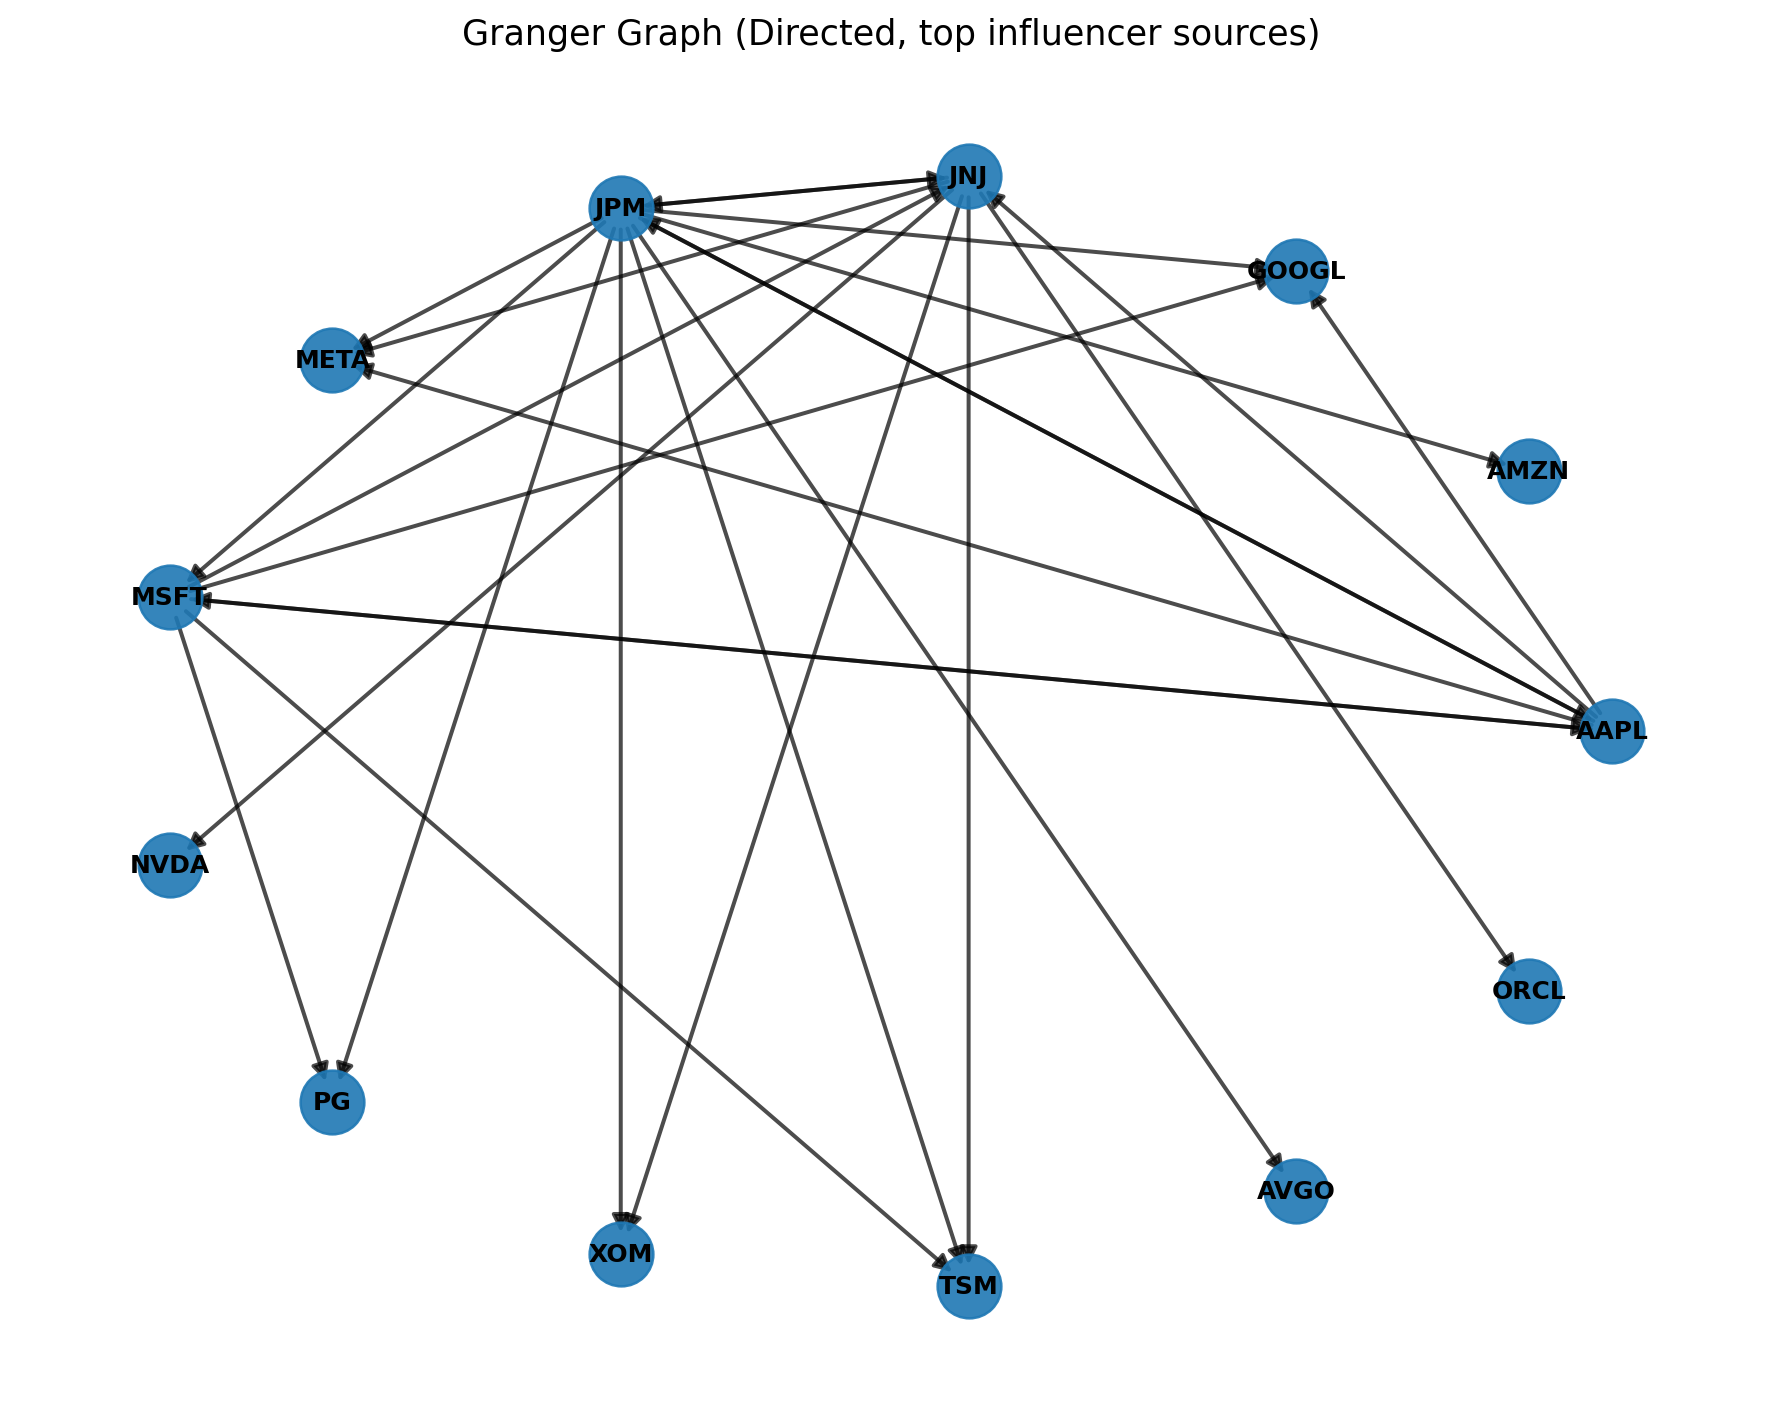

Total Granger edges: 39
Shown edges: 26
Top influencer sources: ['AAPL', 'JNJ', 'JPM', 'MSFT']


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

stocks = list(G_train.nodes())
N = len(stocks)

# Build directed Granger graph
Gg = nx.DiGraph()
Gg.add_nodes_from(stocks)

for i, tgt in enumerate(stocks):
    for j, src in enumerate(stocks):
        if i != j and A[i, j] > 0:
            Gg.add_edge(src, tgt)  # src causes tgt

# OPTIONAL readability filter: keep only edges from top-k "influencer" nodes
k_sources = 4
top_sources = sorted(Gg.out_degree, key=lambda x: x[1], reverse=True)[:k_sources]
top_sources = {n for n, d in top_sources}

Gg_show = nx.DiGraph()
Gg_show.add_nodes_from(stocks)
for u, v in Gg.edges():
    if u in top_sources:
        Gg_show.add_edge(u, v)

plt.figure(figsize=(10, 8), dpi=180)

# Use the SAME circular layout style
pos = nx.circular_layout(Gg_show)

nx.draw_networkx_nodes(Gg_show, pos, node_size=650, alpha=0.9)
nx.draw_networkx_labels(Gg_show, pos, font_size=10, font_weight="bold")

nx.draw_networkx_edges(
    Gg_show, pos,
    arrows=True, arrowstyle="-|>", arrowsize=14,
    width=1.6, alpha=0.7
)

plt.title("Granger Graph (Directed, top influencer sources)", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

print("Total Granger edges:", Gg.number_of_edges())
print("Shown edges:", Gg_show.number_of_edges())
print("Top influencer sources:", sorted(list(top_sources)))

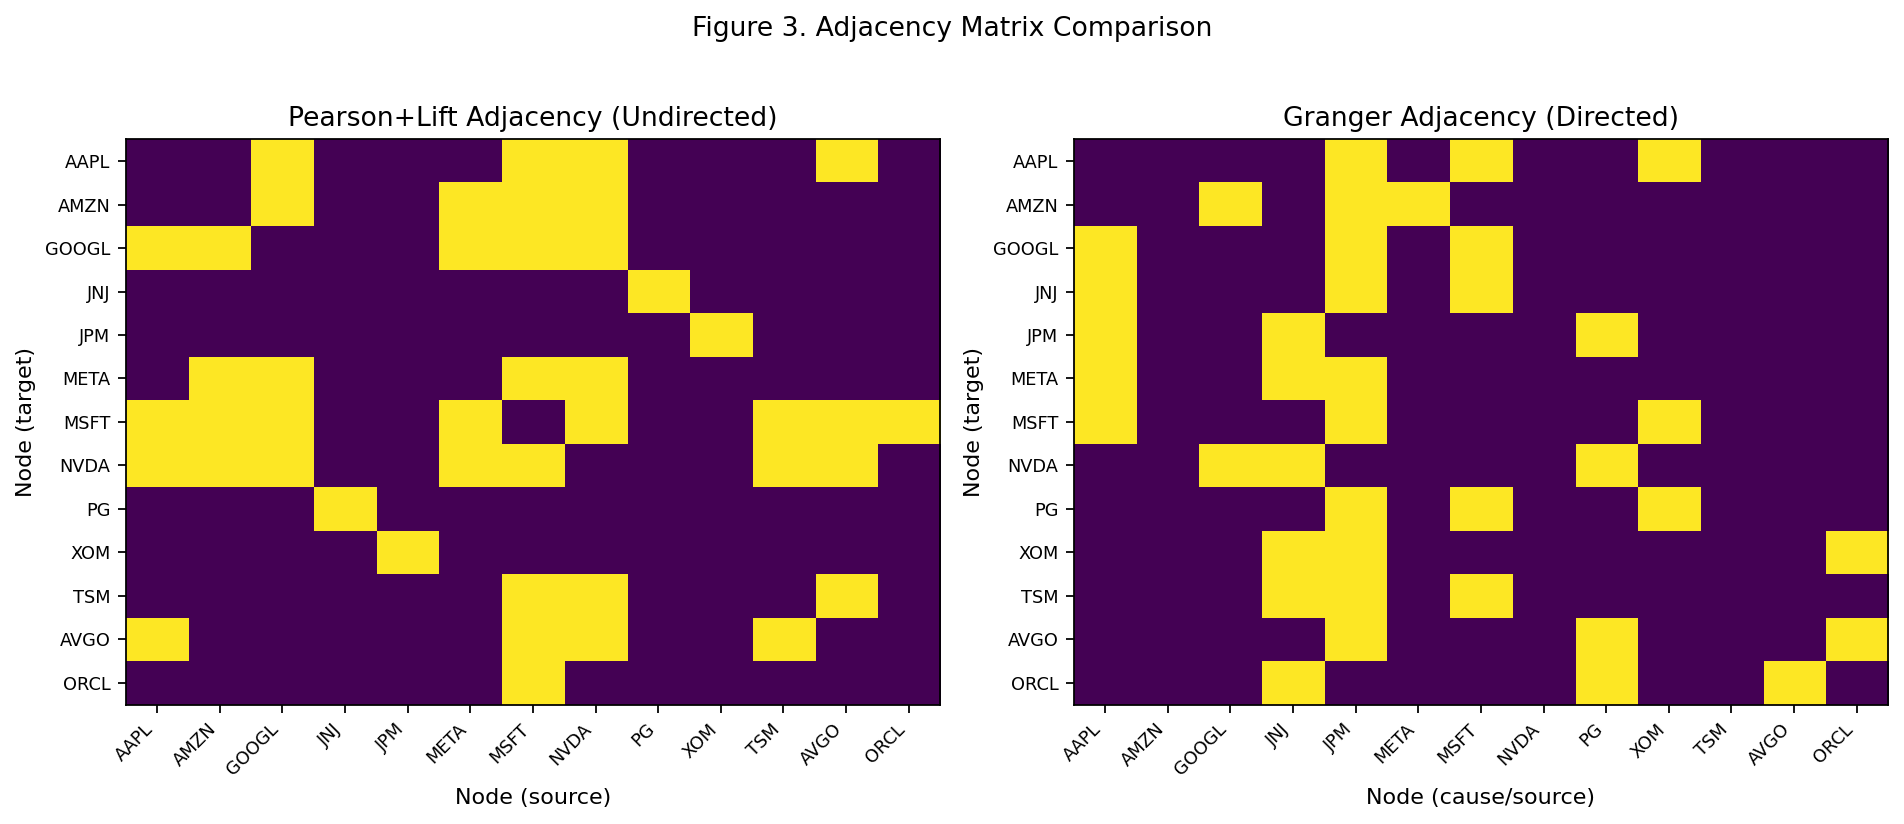

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

stocks = list(G_train.nodes())
N = len(stocks)

# Pearson adjacency (0/1)
A_pearson = nx.to_numpy_array(G_train, nodelist=stocks)
A_pearson = (A_pearson > 0).astype(int)

# Granger adjacency matrix A (already 0/1) should be same shape [N,N]
A_granger = (A > 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=160)

im0 = axes[0].imshow(A_pearson, aspect="auto")
axes[0].set_title("Pearson+Lift Adjacency (Undirected)")
axes[0].set_xlabel("Node (source)")
axes[0].set_ylabel("Node (target)")

im1 = axes[1].imshow(A_granger, aspect="auto")
axes[1].set_title("Granger Adjacency (Directed)")
axes[1].set_xlabel("Node (cause/source)")
axes[1].set_ylabel("Node (target)")

# Optional: show only a few tick labels to avoid clutter
step = max(1, N // 10)
ticks = np.arange(0, N, step)
for ax in axes:
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    ax.set_xticklabels([stocks[i] for i in ticks], rotation=45, ha="right", fontsize=8)
    ax.set_yticklabels([stocks[i] for i in ticks], fontsize=8)

plt.suptitle("Figure 3. Adjacency Matrix Comparison", y=1.02)
plt.tight_layout()
plt.show()

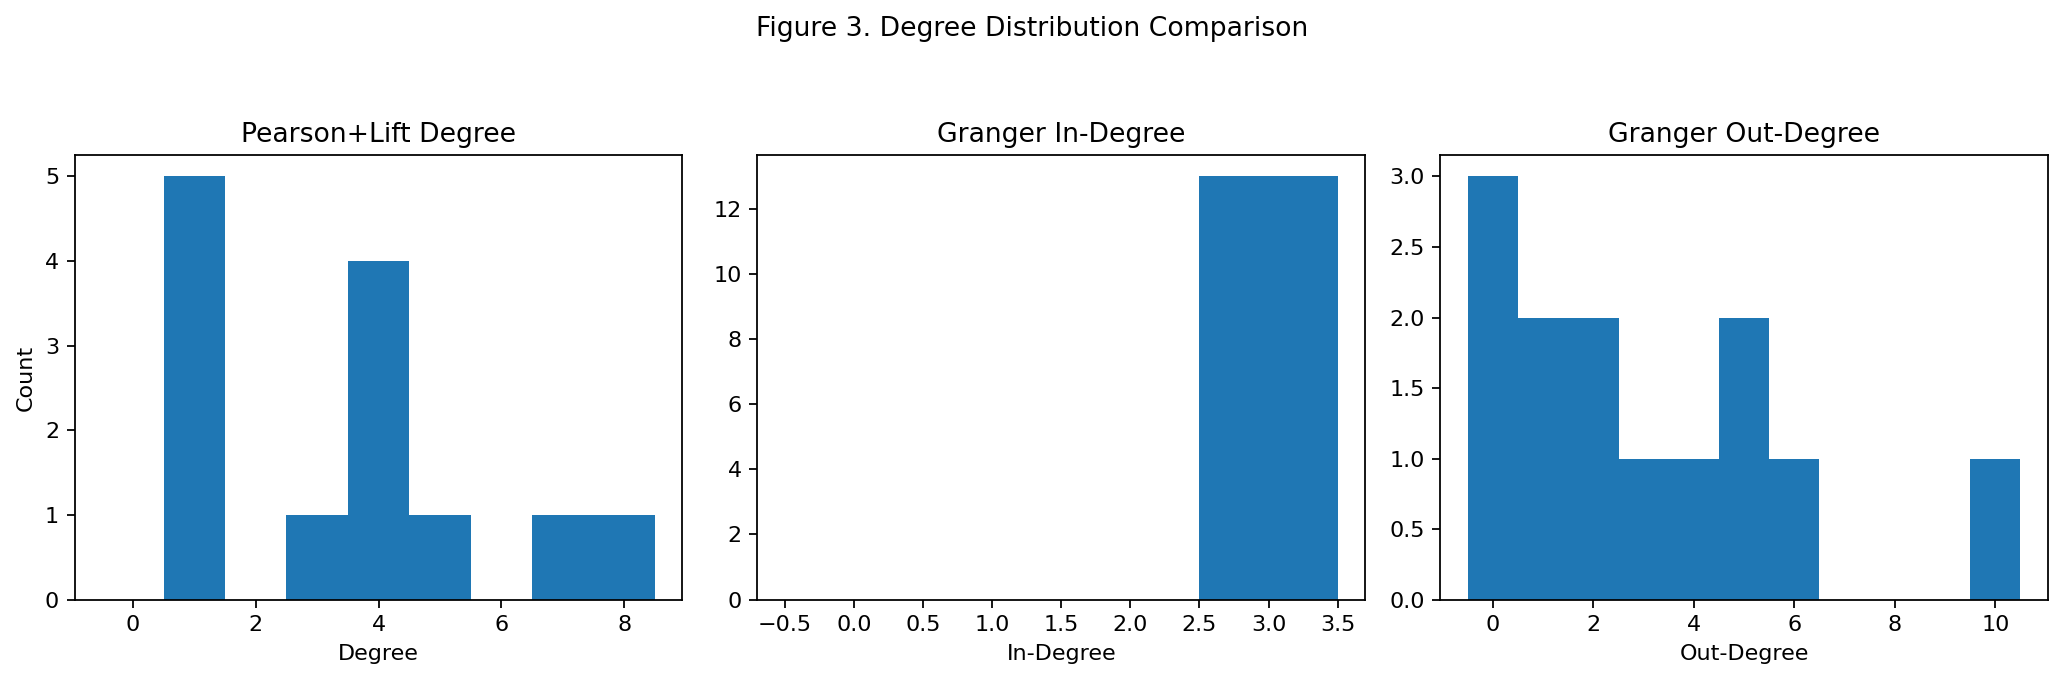

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

stocks = list(G_train.nodes())

# Pearson degrees (undirected)
deg_pearson = np.array([d for _, d in G_train.degree()])

# Build Granger directed graph as in Option A
G_granger = nx.DiGraph()
G_granger.add_nodes_from(stocks)
for i, tgt in enumerate(stocks):
    for j, src in enumerate(stocks):
        if i != j and A[i, j] > 0:
            G_granger.add_edge(src, tgt)

in_deg = np.array([d for _, d in G_granger.in_degree()])
out_deg = np.array([d for _, d in G_granger.out_degree()])

fig, axes = plt.subplots(1, 3, figsize=(13, 4), dpi=160)

axes[0].hist(deg_pearson, bins=range(int(deg_pearson.max())+2), align="left")
axes[0].set_title("Pearson+Lift Degree")
axes[0].set_xlabel("Degree")
axes[0].set_ylabel("Count")

axes[1].hist(in_deg, bins=range(int(in_deg.max())+2), align="left")
axes[1].set_title("Granger In-Degree")
axes[1].set_xlabel("In-Degree")

axes[2].hist(out_deg, bins=range(int(out_deg.max())+2), align="left")
axes[2].set_title("Granger Out-Degree")
axes[2].set_xlabel("Out-Degree")

plt.suptitle("Figure 3. Degree Distribution Comparison", y=1.05)
plt.tight_layout()
plt.show()

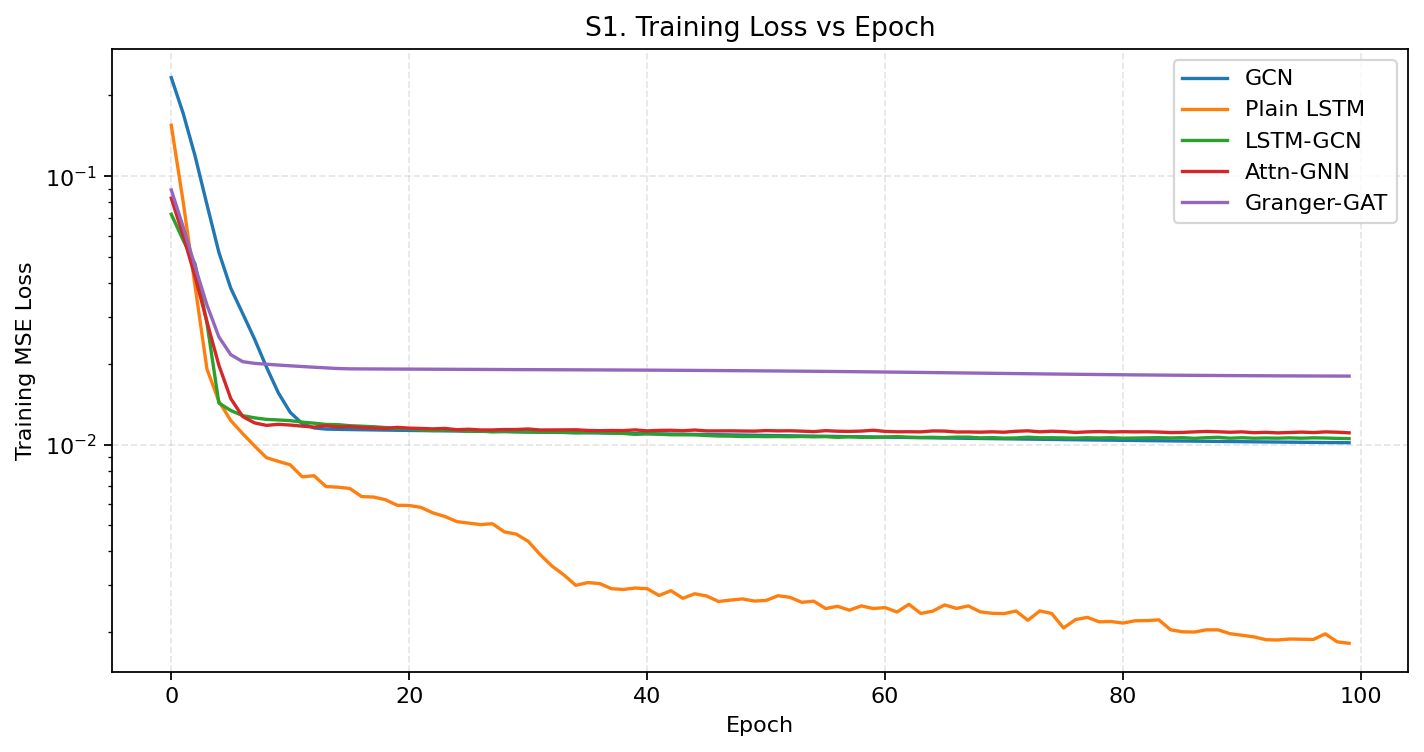

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 4.8), dpi=160)

for model_name, losses in train_loss_history.items():
    plt.plot(losses, label=model_name)

plt.title("S1. Training Loss vs Epoch")
plt.ylabel("Training MSE Loss")
plt.yscale("log")
plt.xlabel("Epoch")
plt.grid(True, linestyle="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# from statsmodels.tsa.stattools import grangercausalitytests

# stocks = list(df.select_dtypes("number").columns)
# num_stocks = len(stocks)

# # min-max scaling for prediction, same as before
# df[stocks] = (df[stocks] - df[stocks].min()) / (df[stocks].max() - df[stocks].min())

# # last-month split
# cutoff_date = df.index.max() - pd.Timedelta(days=30)
# train_data = df[df.index < cutoff_date].copy()
# test_data = df[df.index >= cutoff_date].copy()

# # use returns to build Granger graph
# returns = df[stocks].pct_change().dropna()

# max_lag = 5
# p_thresh = 0.05
# A = np.zeros((num_stocks, num_stocks))

# for i, stock_i in enumerate(stocks):
#     for j, stock_j in enumerate(stocks):
#         if i == j:
#             continue
#         try:
#             data = returns[[stock_j, stock_i]].dropna()
#             test_result = grangercausalitytests(data, maxlag=max_lag, verbose=False)
#             min_p = min(test_result[lag][0]["ssr_ftest"][1] for lag in range(1, max_lag + 1))
#             if min_p < p_thresh:
#                 A[j, i] = 1  # stock_j -> stock_i
#         except:
#             pass

# # add self-loops and normalize
# A = A + np.eye(num_stocks)
# D = np.diag(np.sum(A, axis=1))
# D_inv_sqrt = np.linalg.inv(np.sqrt(D))
# A_hat = D_inv_sqrt @ A @ D_inv_sqrt
# A_hat = torch.tensor(A_hat, dtype=torch.float32)

# # one-step prediction
# X_train = torch.tensor(train_data[stocks].values[:-1], dtype=torch.float32)
# y_train = torch.tensor(train_data[stocks].values[1:], dtype=torch.float32)
# X_test = torch.tensor(test_data[stocks].values[:-1], dtype=torch.float32)
# y_test = torch.tensor(test_data[stocks].values[1:], dtype=torch.float32)

# class GCNLayer(nn.Module):
#     def __init__(self, in_features, out_features):
#         super().__init__()
#         self.linear = nn.Linear(in_features, out_features)

#     def forward(self, X, A):
#         X = torch.matmul(A, X)
#         return self.linear(X)

# class StockGNN(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.gcn1 = GCNLayer(1, 16)
#         self.gcn2 = GCNLayer(16, 1)

#     def forward(self, x, A):
#         x = x.reshape(-1, 1)
#         x = self.gcn1(x, A)
#         x = F.relu(x)
#         x = self.gcn2(x, A)
#         return x.squeeze()

# model = StockGNN()
# optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
# loss_fn = nn.MSELoss()
# epochs = 100

# for epoch in range(epochs):
#     total_loss = 0
#     model.train()
#     for t in range(X_train.shape[0]):
#         optimizer.zero_grad()
#         pred = model(X_train[t], A_hat)
#         loss = loss_fn(pred, y_train[t])
#         loss.backward()
#         optimizer.step()
#         total_loss += loss.item()

#     if epoch % 10 == 0:
#         print(f"Epoch {epoch}, Train Loss: {total_loss / X_train.shape[0]:.4f}")

# model.eval()
# predictions = []
# with torch.no_grad():
#     for t in range(X_test.shape[0]):
#         pred = model(X_test[t], A_hat)
#         predictions.append(pred.numpy())

# predictions = np.array(predictions)

# mse_scores = {}
# for i, stock in enumerate(stocks):
#     mse_scores[stock] = mean_squared_error(y_test[:, i].numpy(), predictions[:, i])

# mean_mse = sum(mse_scores.values()) / len(mse_scores)

# print("Mean Squared Error (MSE) for each stock:")
# for stock, mse in mse_scores.items():
#     print(f"{stock}: {mse:.4f}")

# print("\nMean MSE for all stocks:")
# print(mean_mse)